# AI Agent Skills 各领域推荐集合构建与可视化分析

## 项目背景

随着 AI Agent 应用场景不断扩展，Skill 可以理解为面向某一类具体任务的能力模块，例如代码开发、营销增长、科研分析、文档处理、视频理解、RAG 检索、安全审计等。不同领域的 Skill 数量多、来源杂、质量差异明显，如果直接查看原始列表，很难快速判断每个领域有哪些值得优先使用的 Skill。

因此，本项目的核心目标不是单纯描述 Skill 生态，而是基于已完成的数据预处理结果，构建一个“各个领域的 Skill 推荐集合”。也就是先对社区 Skill 进行领域划分，再结合 GitHub 热度、维护活跃度、文档质量、项目可信度和功能明确度等指标进行评分，最后为每个领域筛选出具有代表性的推荐 Skill。

本 Notebook 用于按照论文/课程作业结构展示该推荐集合的构建过程，并在后续可视化分析阶段展示数据结构、评分分布和推荐结果。

## 一、研究目标与任务定义

本项目的主要研究目标是：**构建一个面向不同应用领域的 AI Agent Skills 推荐集合**。

具体任务包括：

1. 对原始 Skill 数据进行整理，区分官方 Skill 与社区 Skill。
2. 针对社区 Skill，根据名称、描述和类别信息划分应用领域。
3. 建立综合评分规则，从多个维度评价每个 Skill 的推荐价值。
4. 在每个领域中筛选出推荐 Skill，形成“领域—推荐 Skill—具体作用—推荐等级”的集合。
5. 通过图表和表格展示推荐集合的构建结果，为论文撰写提供依据。

因此，后文中的来源结构、场景分布、评分分布、GitHub 指标关系等内容，都是为了说明推荐集合是如何形成的，属于可视化分析阶段。

## 二、数据来源与推荐集合构建思路

本项目使用的数据文件为 `data/visualization_data.json`，该文件由 `generate_visualization_data.py` 生成。

推荐集合构建的基本思路如下：

1. **数据输入**：读取预处理后的 Skill 数据和 GitHub 仓库指标数据。
2. **来源识别**：将 Skill 分为官方来源和社区来源。官方 Skill 用于总体供给分析，社区 Skill 用于重点推荐。
3. **领域划分**：根据 Skill 名称、描述和原始分类中的关键词，将社区 Skill 归入安全、法律、金融、教育、科研、电商、SEO、社媒、视频、图片、语音、写作、文档、开发、自动化、RAG 等领域。
4. **综合评分**：根据场景匹配度、GitHub 热度、维护活跃度、文档质量、项目可信度和功能明确度计算推荐得分。
5. **分领域推荐**：每个领域按照推荐得分排序，选择若干代表性 Skill，形成最终的各领域推荐集合。

主要字段包括：

- `community_categories`：每个领域的 Skill 数量和推荐列表。
- `enriched_community_skills`：每个社区 Skill 的评分、评级、领域、具体作用和 GitHub 指标。
- `score_model`：推荐评分模型及各维度权重。

In [46]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display, Image, Markdown

DATA_PATH = Path('data/visualization_data.json')
FIGURE_DIR = Path('outputs/figures')
TABLE_DIR = Path('outputs/tables')

with DATA_PATH.open('r', encoding='utf-8') as f:
    data = json.load(f)

overview = data['overview']
overview

{'total': 1114,
 'official_total': 586,
 'community_total': 528,
 'official_company_count': 48,
 'community_category_count': 22}

## 三、批量生成论文图表

下面代码会调用 `generate_paper_charts.py`，批量生成 PNG、SVG、CSV 和 Markdown 表格文件。

如果已经生成过图表，可以跳过该单元；如果数据更新，建议重新运行。

In [47]:
import generate_paper_charts

generate_paper_charts.main()

论文图表生成完成。
图文件：44 组，输出目录：outputs/figures
表文件：16 组，输出目录：outputs/tables
图表索引：outputs/chart_index.md


## 四、可视化分析结果：数据来源与官方供给

本部分属于可视化分析阶段，用于说明推荐集合的数据基础：整体数据中官方 Skill 与社区 Skill 的比例，以及官方机构的供给情况。

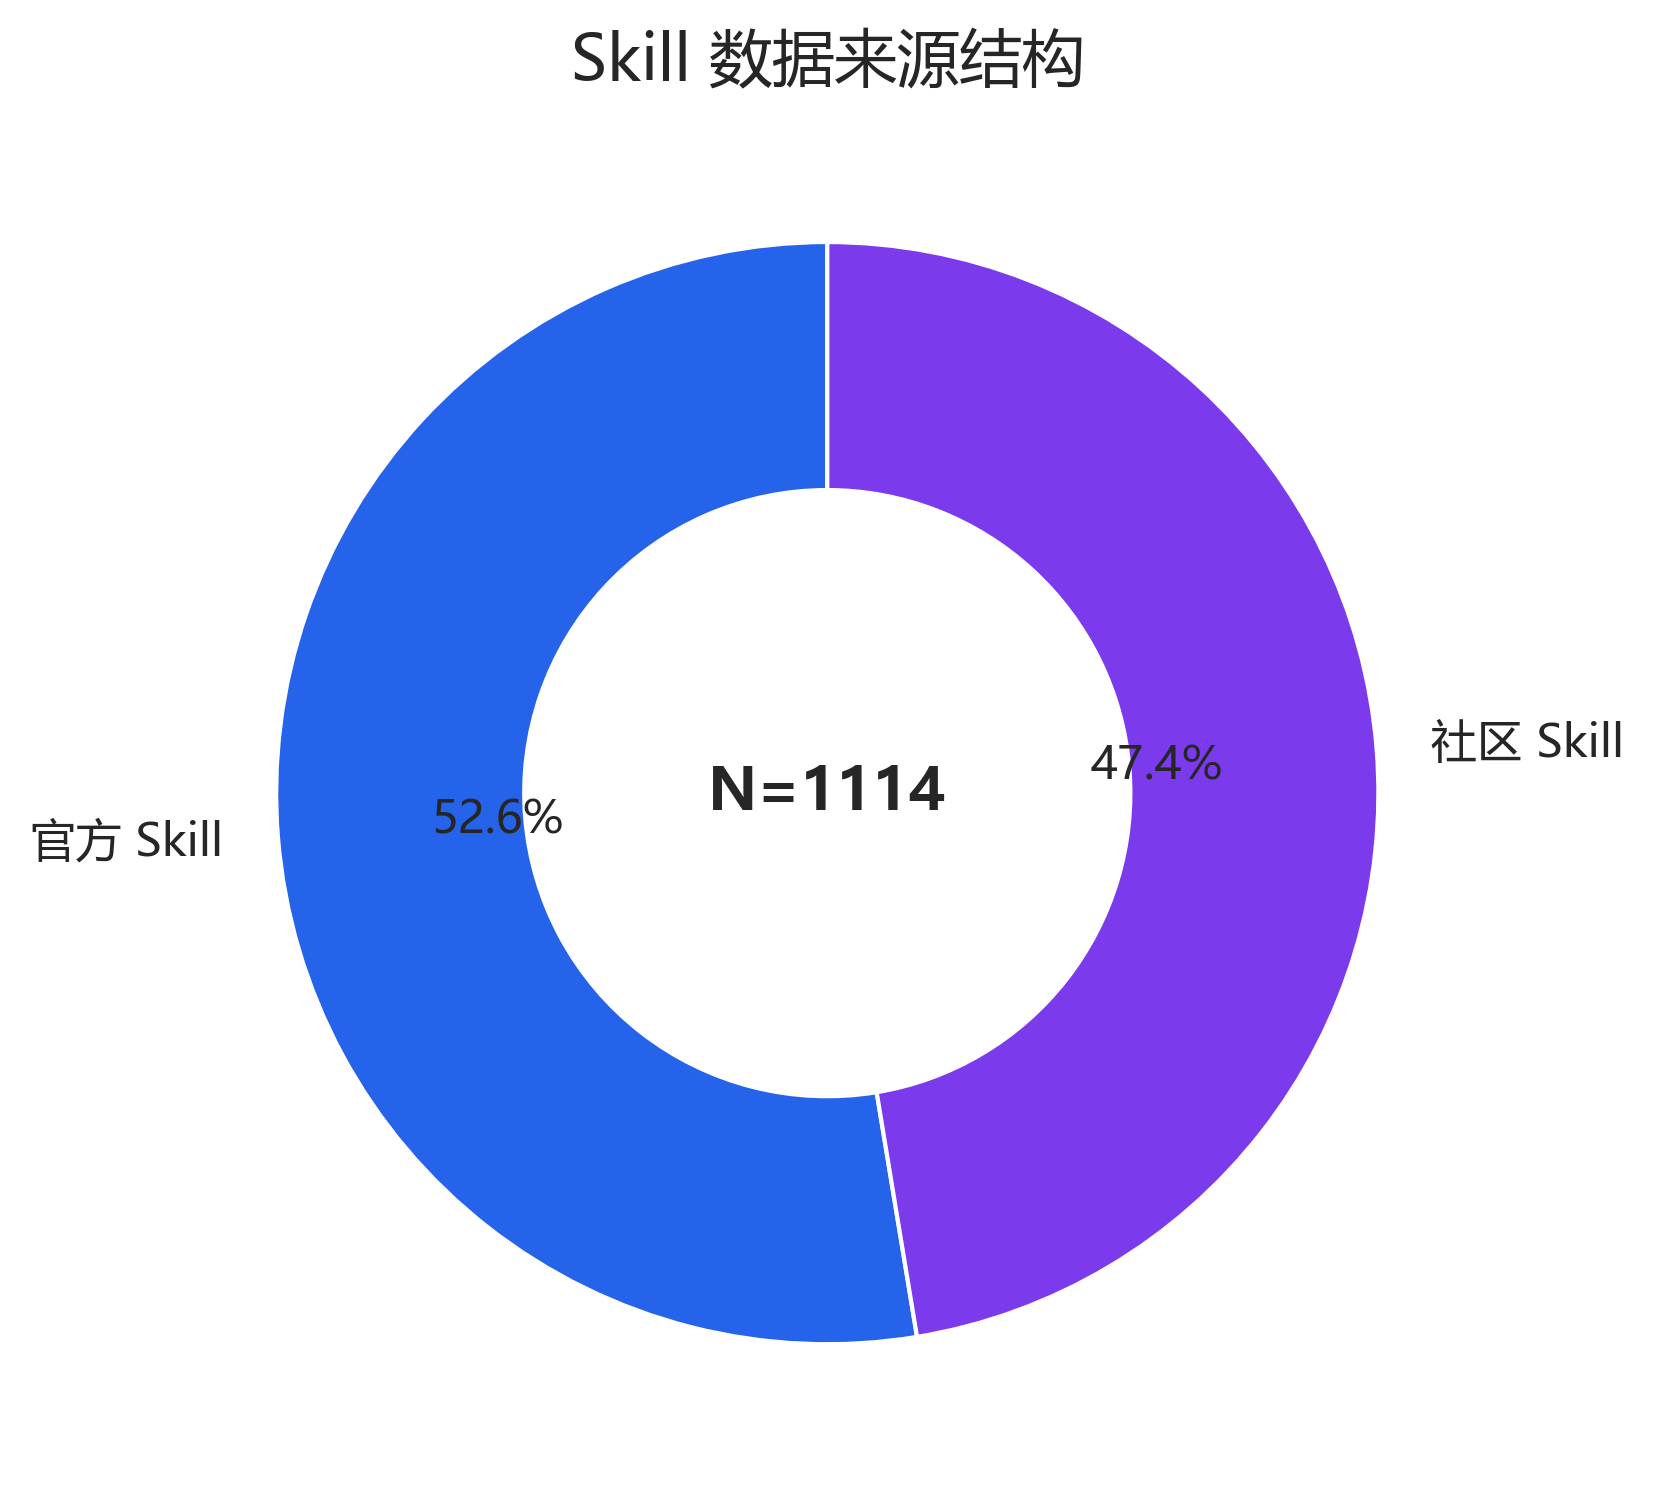

**图1 Skill 数据来源结构。** 该图用于说明官方 Skill 与社区 Skill 在总体数据中的占比。

In [48]:
display(Image(filename=str(FIGURE_DIR / 'fig01_source_structure_pie.png')))
display(Markdown('**图1 Skill 数据来源结构。** 该图用于说明官方 Skill 与社区 Skill 在总体数据中的占比。'))

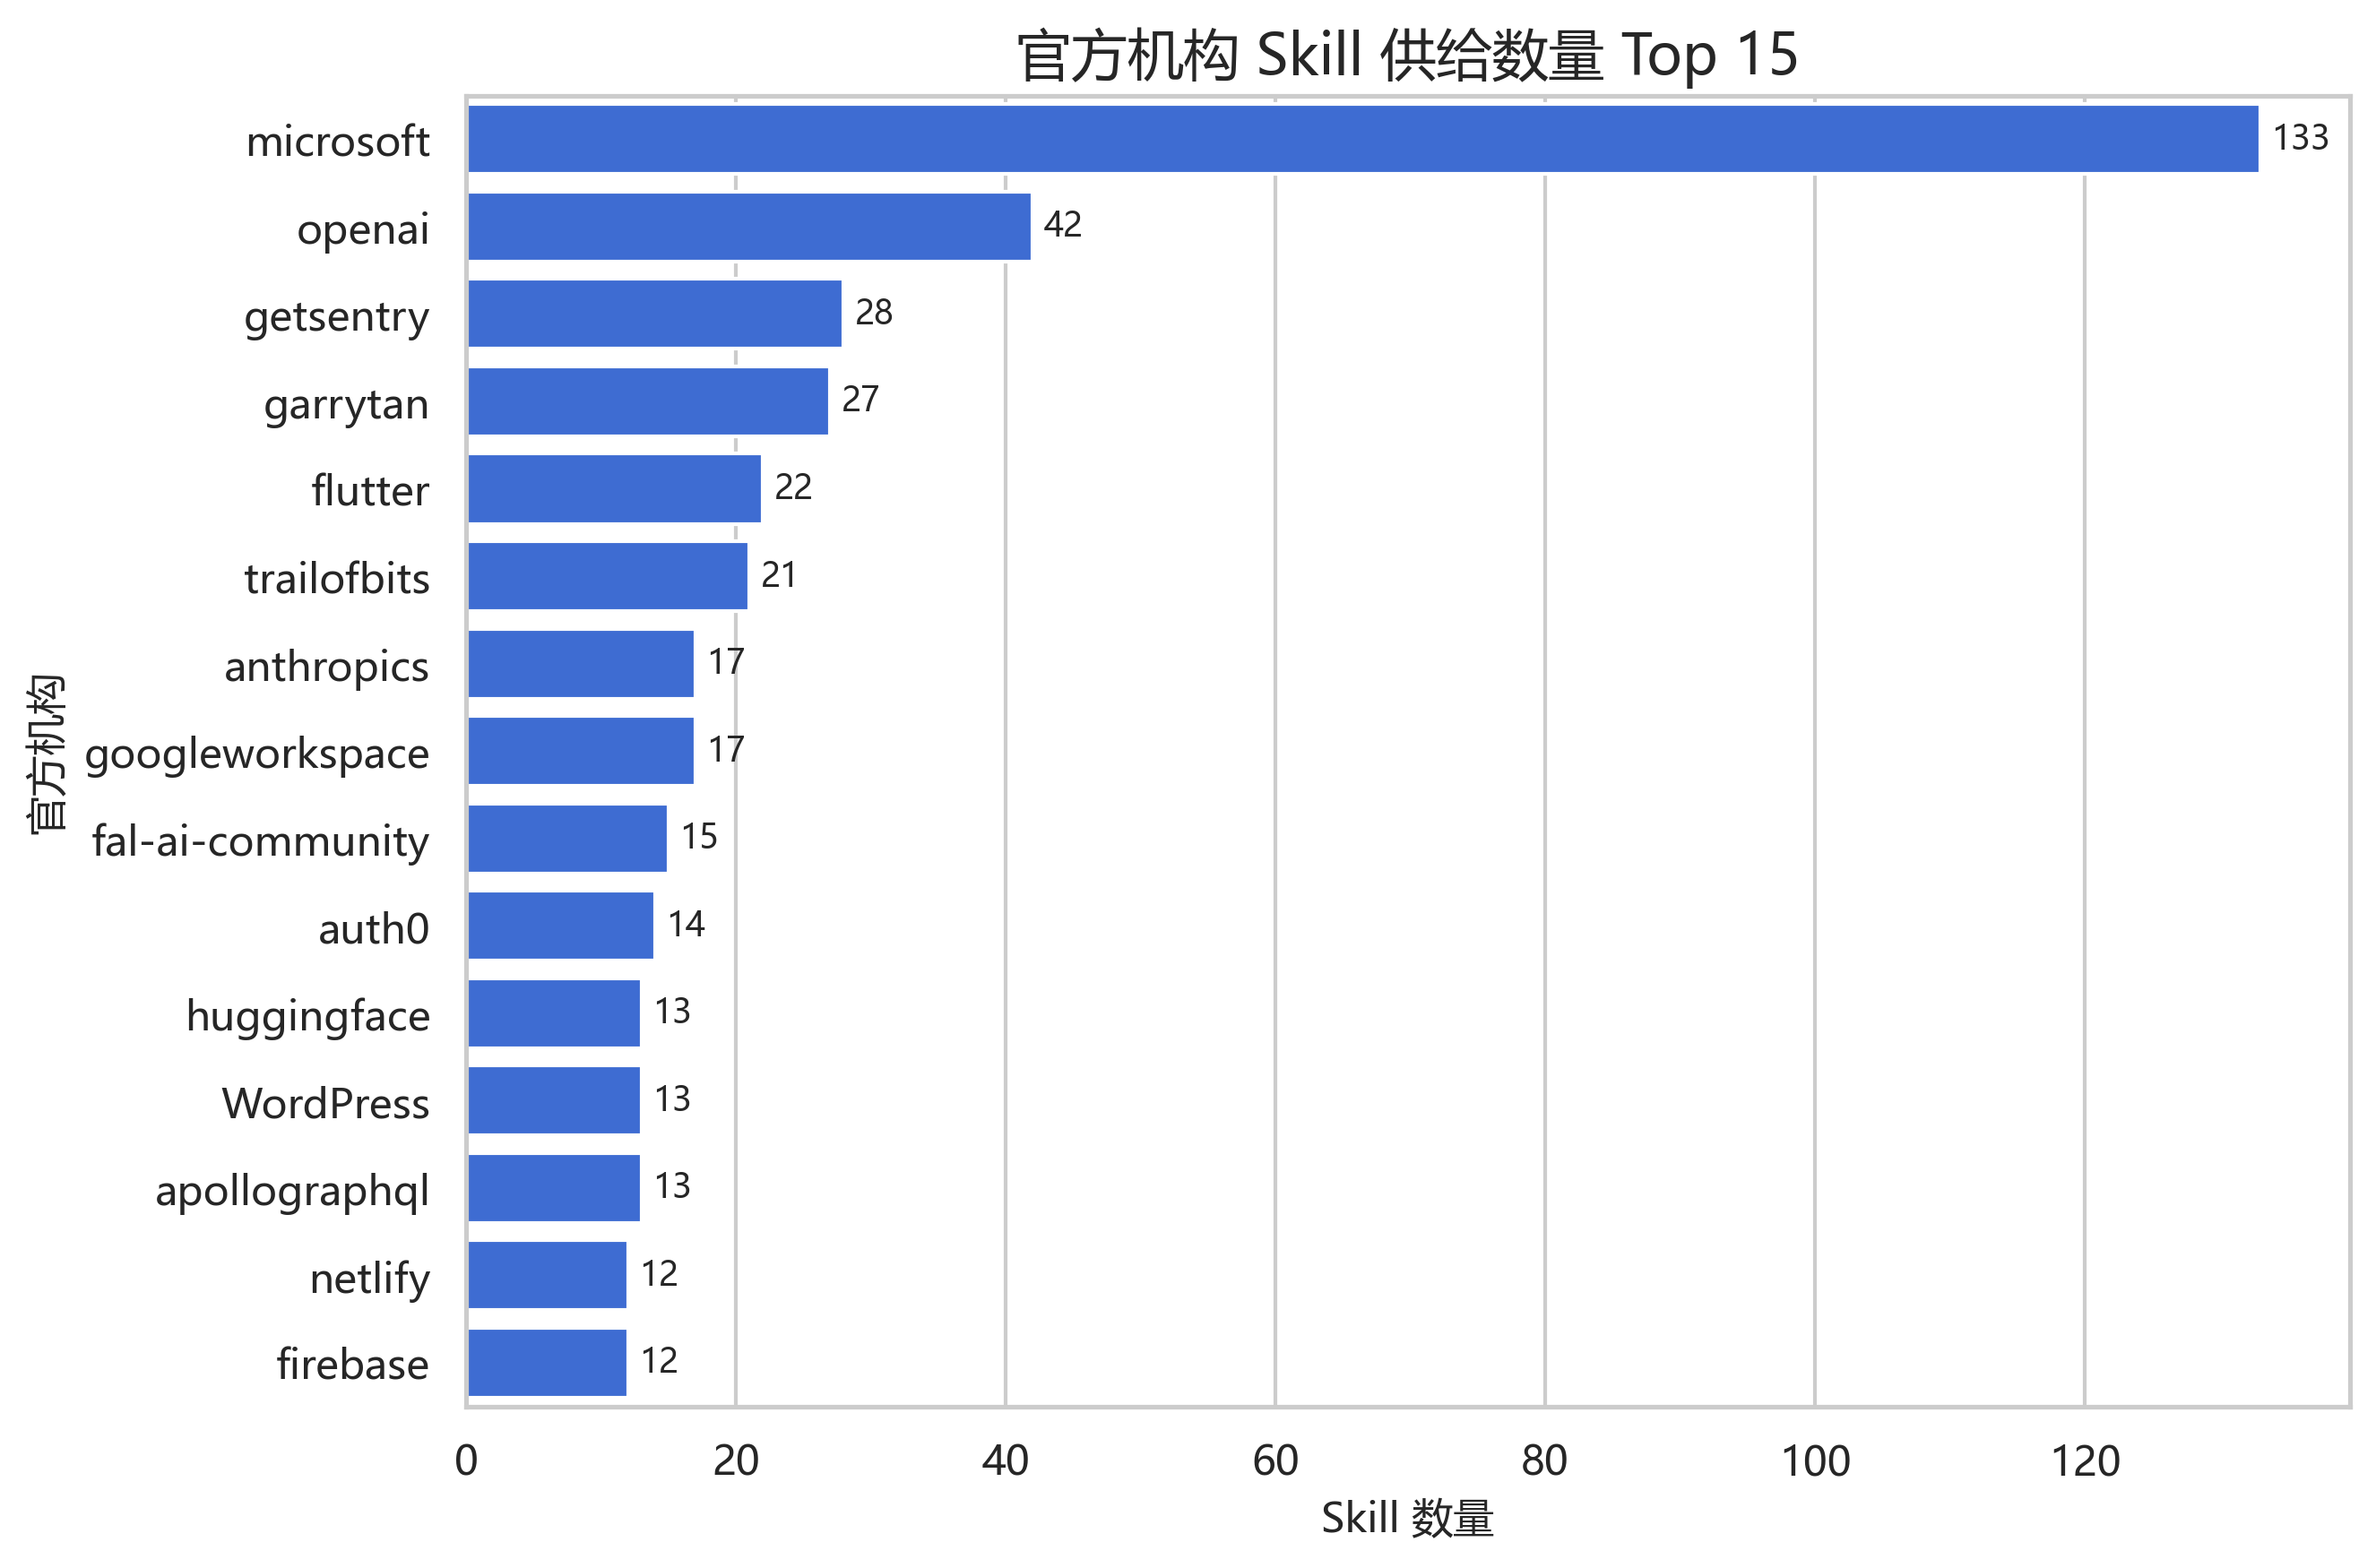

**图2 官方机构 Skill 供给数量 Top 15。** 该图用于分析官方 Skill 生态中的头部机构集中情况。

In [49]:
display(Image(filename=str(FIGURE_DIR / 'fig02_official_company_top15_bar.png')))
display(Markdown('**图2 官方机构 Skill 供给数量 Top 15。** 该图用于分析官方 Skill 生态中的头部机构集中情况。'))

## 五、可视化分析结果：场景分布与评分质量

本部分是论文的重点之一。通过社区 Skill 的领域划分结果，可以看到不同应用领域的 Skill 数量，并进一步形成“各领域 Skill 推荐集合”。

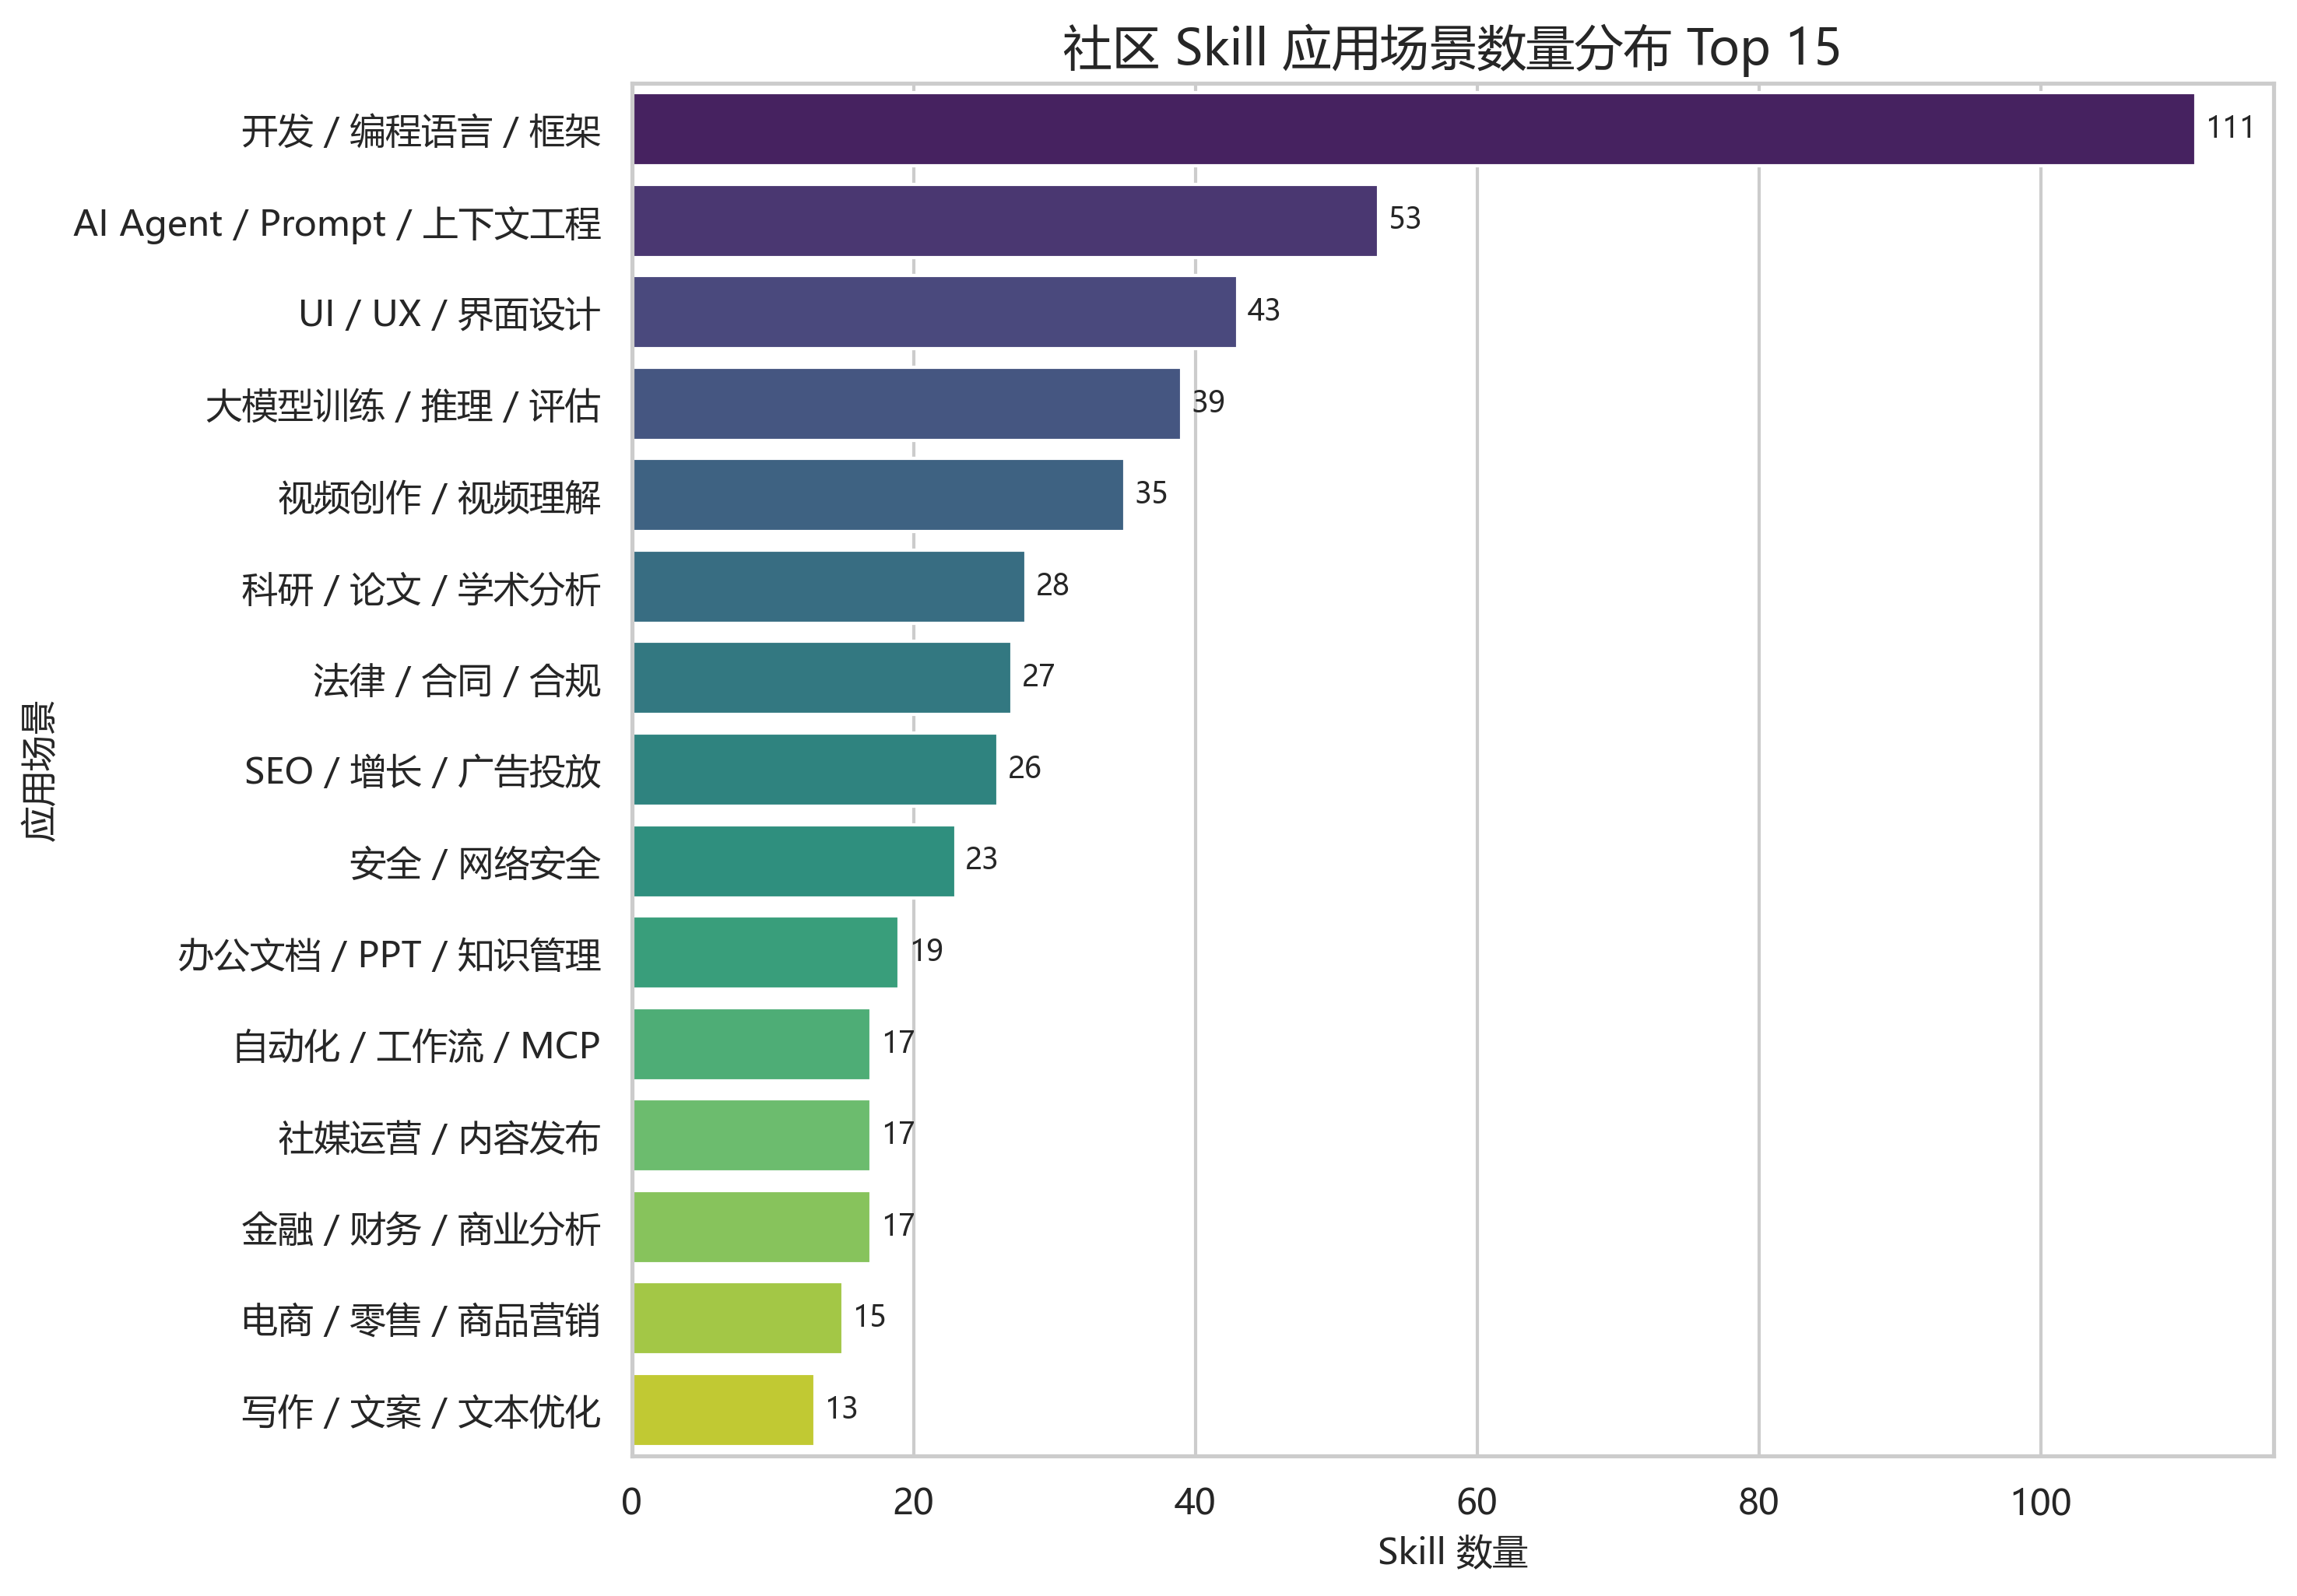

**图3 社区 Skill 应用场景数量分布 Top 15。** 该图展示社区 Skill 的主要应用方向。

In [50]:
display(Image(filename=str(FIGURE_DIR / 'fig03_community_scenario_top15_bar.png')))
display(Markdown('**图3 社区 Skill 应用场景数量分布 Top 15。** 该图展示社区 Skill 的主要应用方向。'))

In [51]:
scenario_table = pd.read_csv(TABLE_DIR / 'table02_scenario_distribution.csv')
display(scenario_table.head(20))

,场景类别,Skill数量,占社区比例(%),推荐数量,代表Skill
0,开发 / 编程语言 / 框架,111,21.02,10,czlonkowski/n8n-code-python
1,AI Agent / Prompt / 上下文工程,53,10.04,8,muratcankoylan/context-fundamentals
2,UI / UX / 界面设计,43,8.14,8,nextlevelbuilder/ui-ux-pro-max-skill
3,大模型训练 / 推理 / 评估,39,7.39,8,NVIDIA/Model-Optimizer/launching-evals
4,视频创作 / 视频理解,35,6.63,8,NVIDIA/video-search-and-summarization/vios
5,科研 / 论文 / 学术分析,28,5.30,5,deanpeters/proto-persona
6,法律 / 合同 / 合规,27,5.11,5,phuryn/privacy-policy
7,SEO / 增长 / 广告投放,26,4.92,5,coreyhaines31/competitor-alternatives
8,安全 / 网络安全,23,4.36,5,mukul975/Anthropic-Cybersecurity-Skills
9,办公文档 / PPT / 知识管理,19,3.60,5,Skill_Seekers


## 六、可视化分析结果：评分分布与场景差异

本部分属于推荐集合的质量分析。评分越高，说明该 Skill 在场景匹配、项目热度、维护活跃度、文档质量、可信度和功能明确度等方面综合表现越好，更适合作为对应领域的推荐对象。

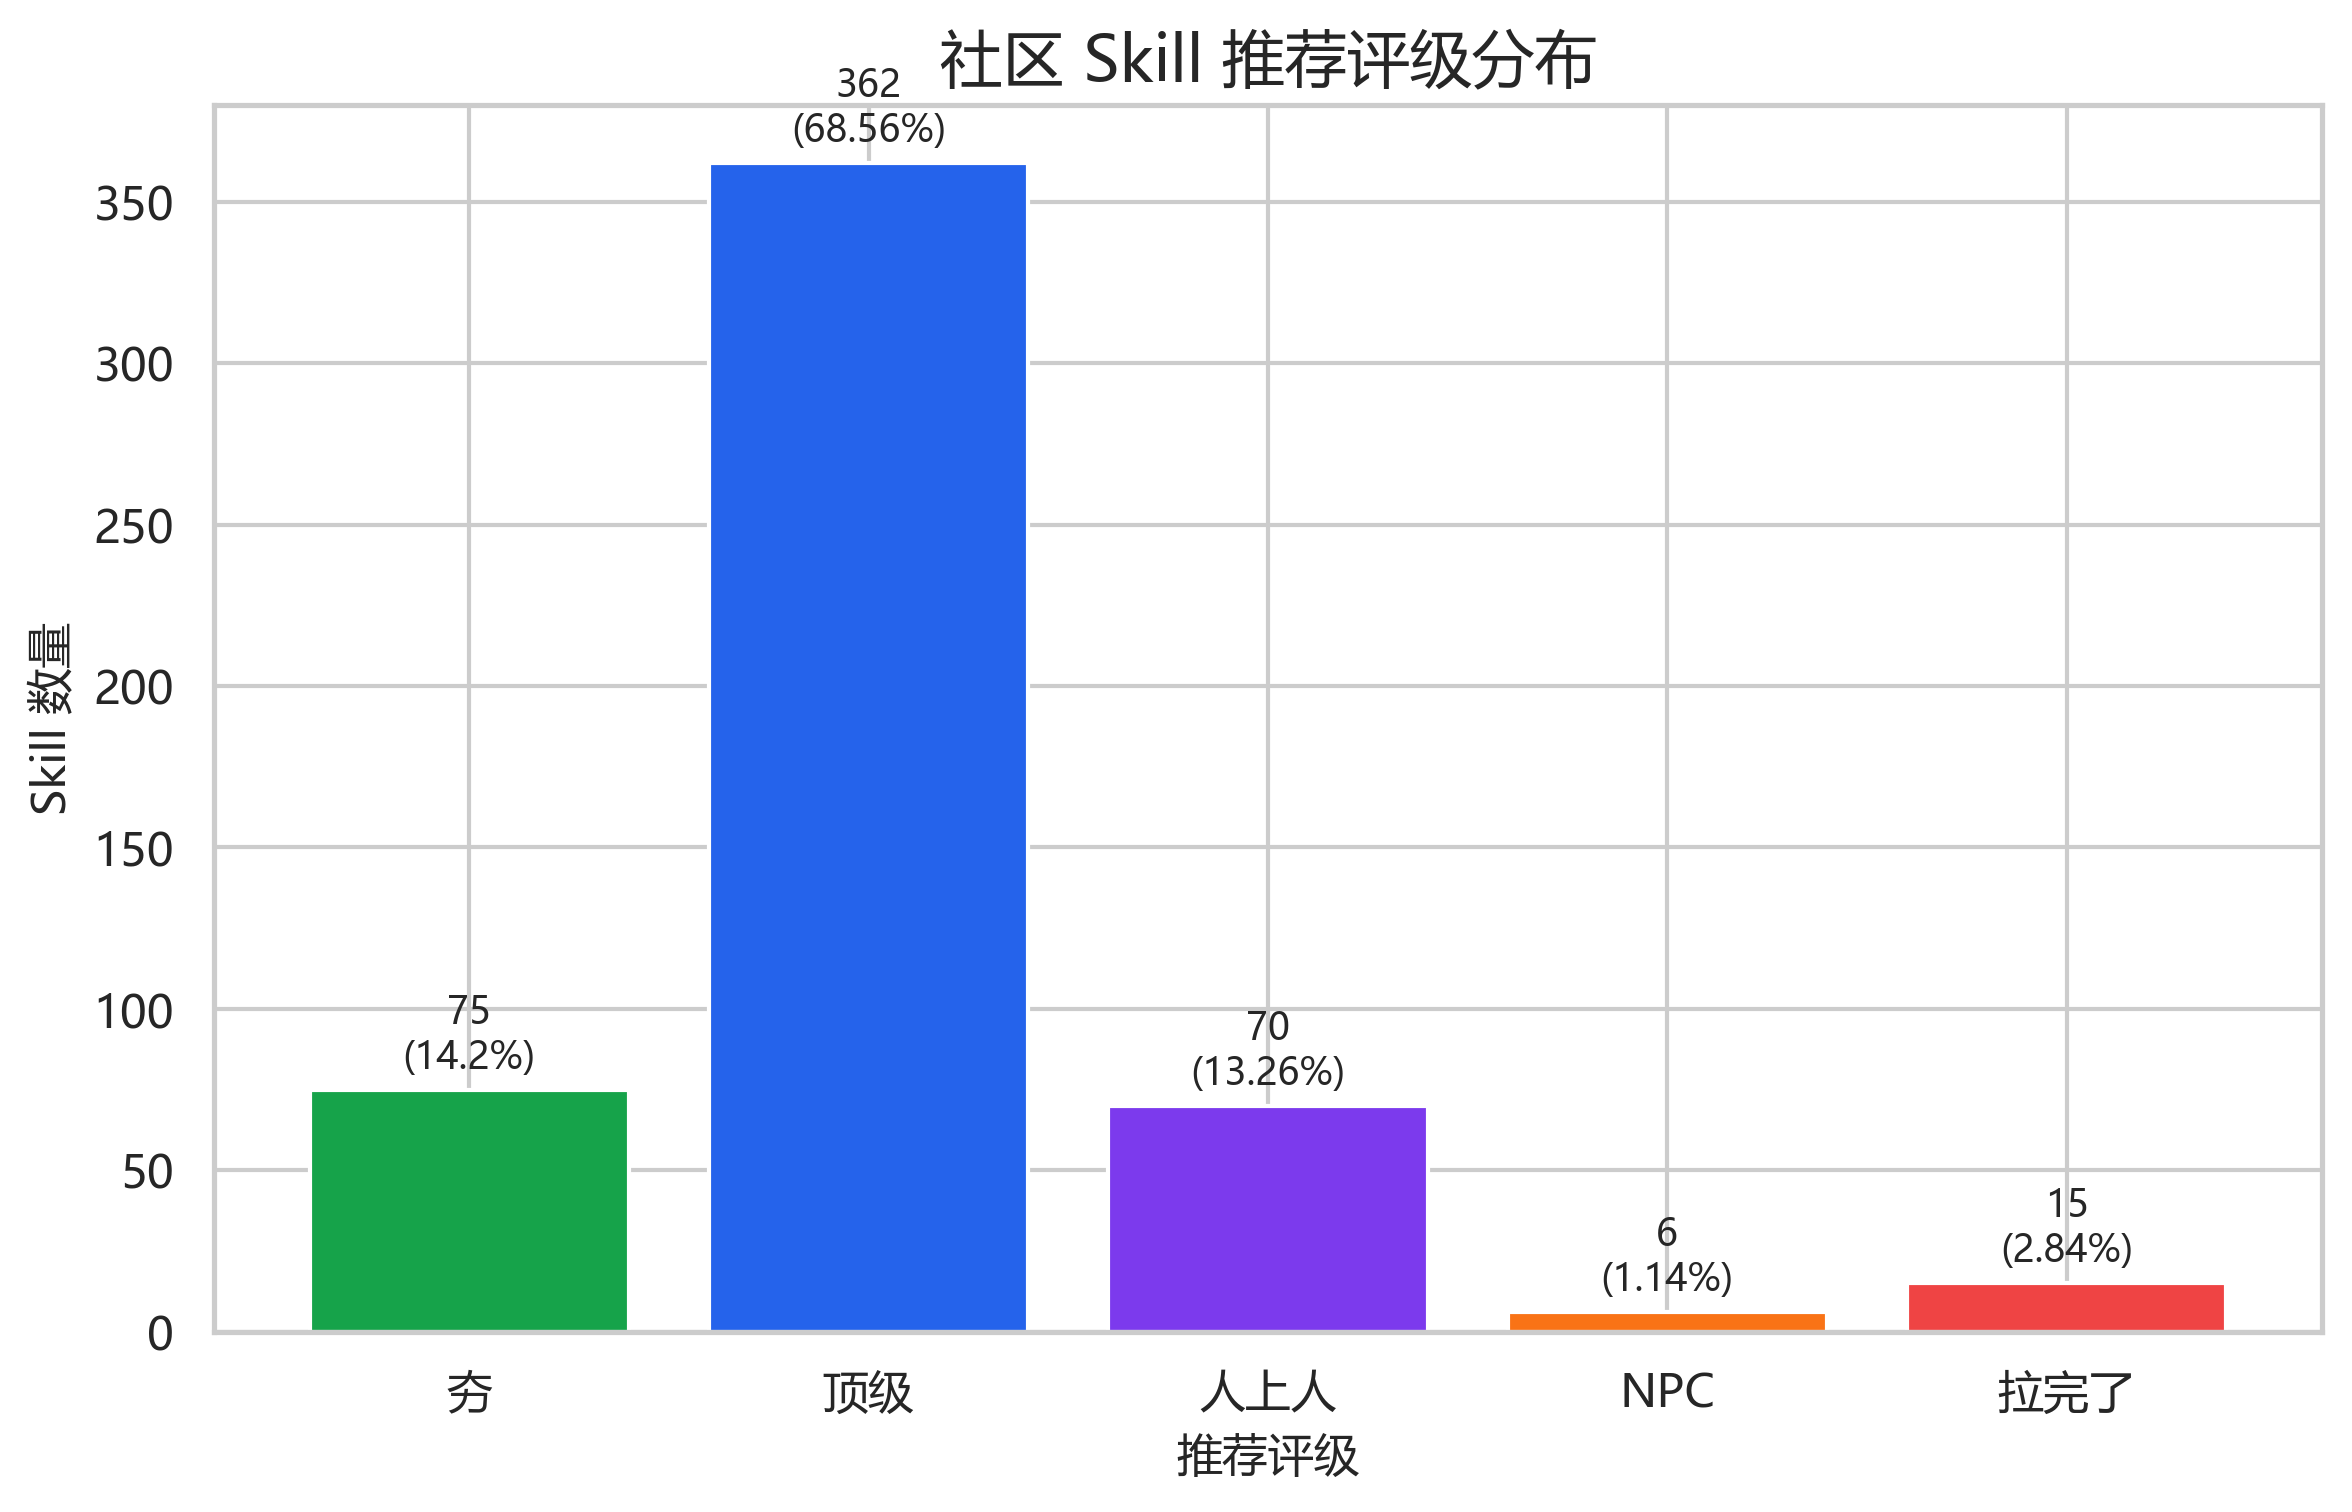

**图4 社区 Skill 推荐评级分布。** 该图用于说明社区项目整体推荐质量的等级结构。

In [52]:
display(Image(filename=str(FIGURE_DIR / 'fig04_rating_distribution_bar.png')))
display(Markdown('**图4 社区 Skill 推荐评级分布。** 该图用于说明社区项目整体推荐质量的等级结构。'))

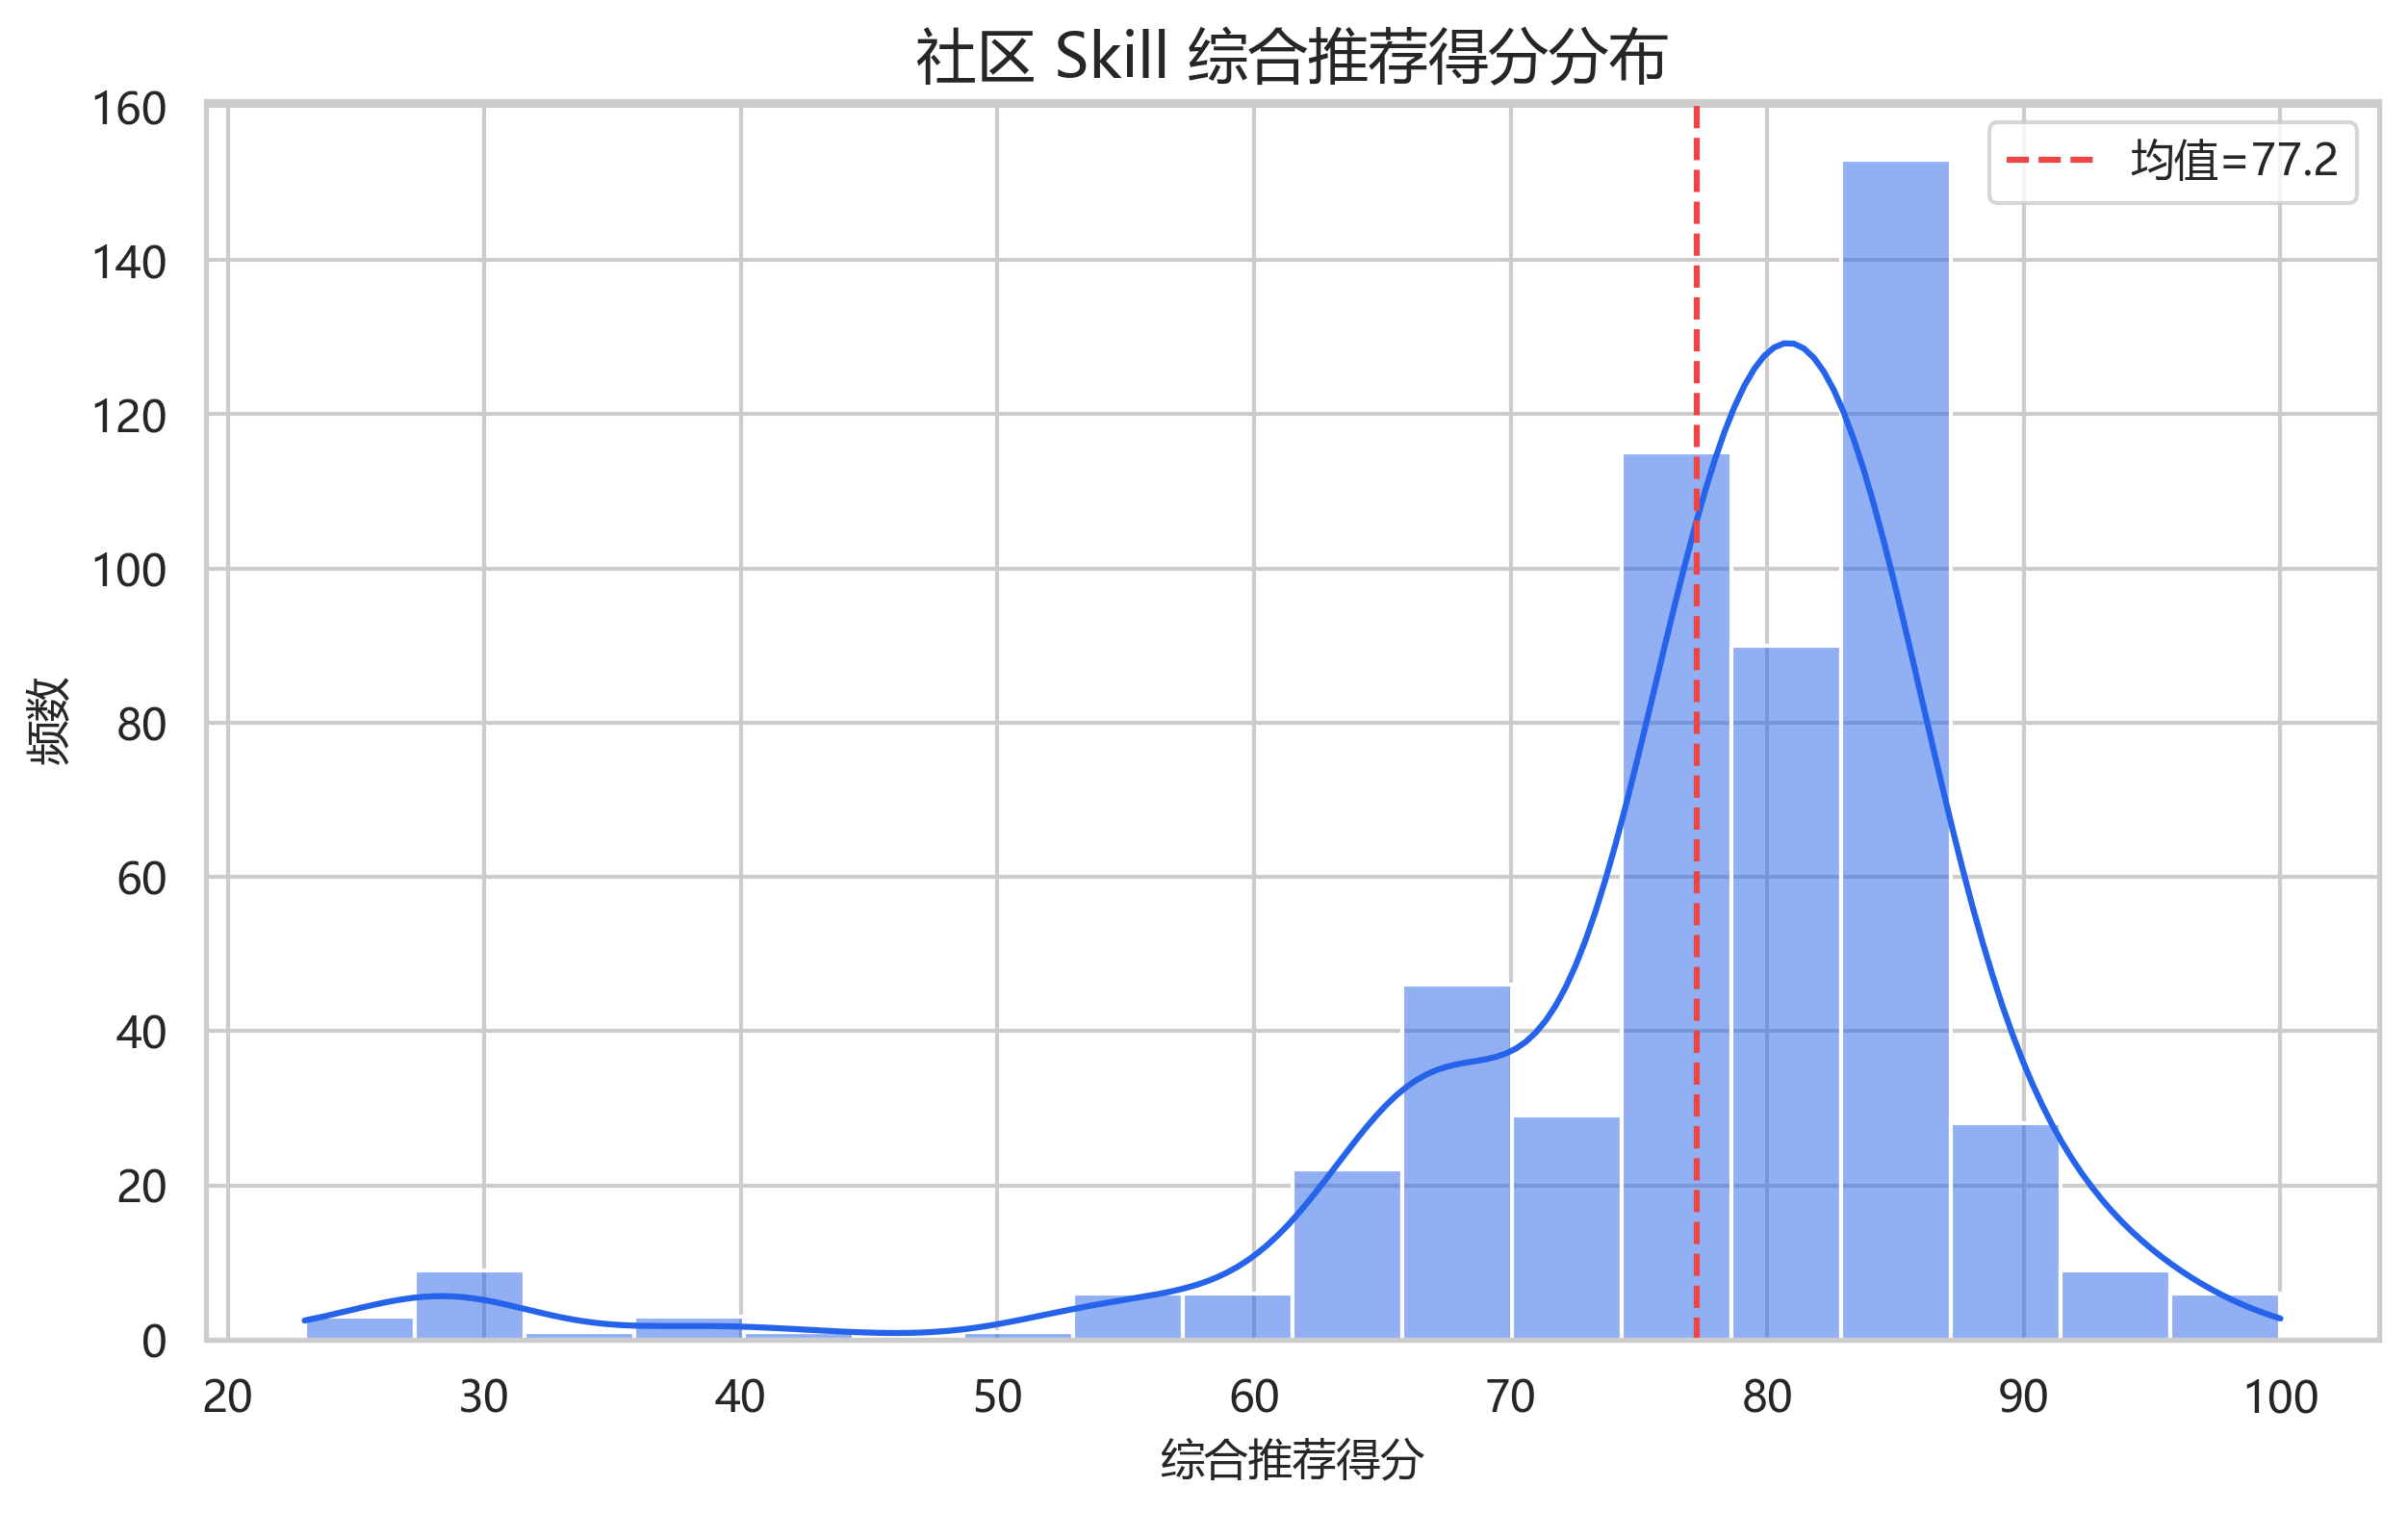

**图5 社区 Skill 综合推荐得分分布。** 该图用于观察推荐分数的集中程度与离散情况。

In [53]:
display(Image(filename=str(FIGURE_DIR / 'fig05_recommend_score_histogram.png')))
display(Markdown('**图5 社区 Skill 综合推荐得分分布。** 该图用于观察推荐分数的集中程度与离散情况。'))

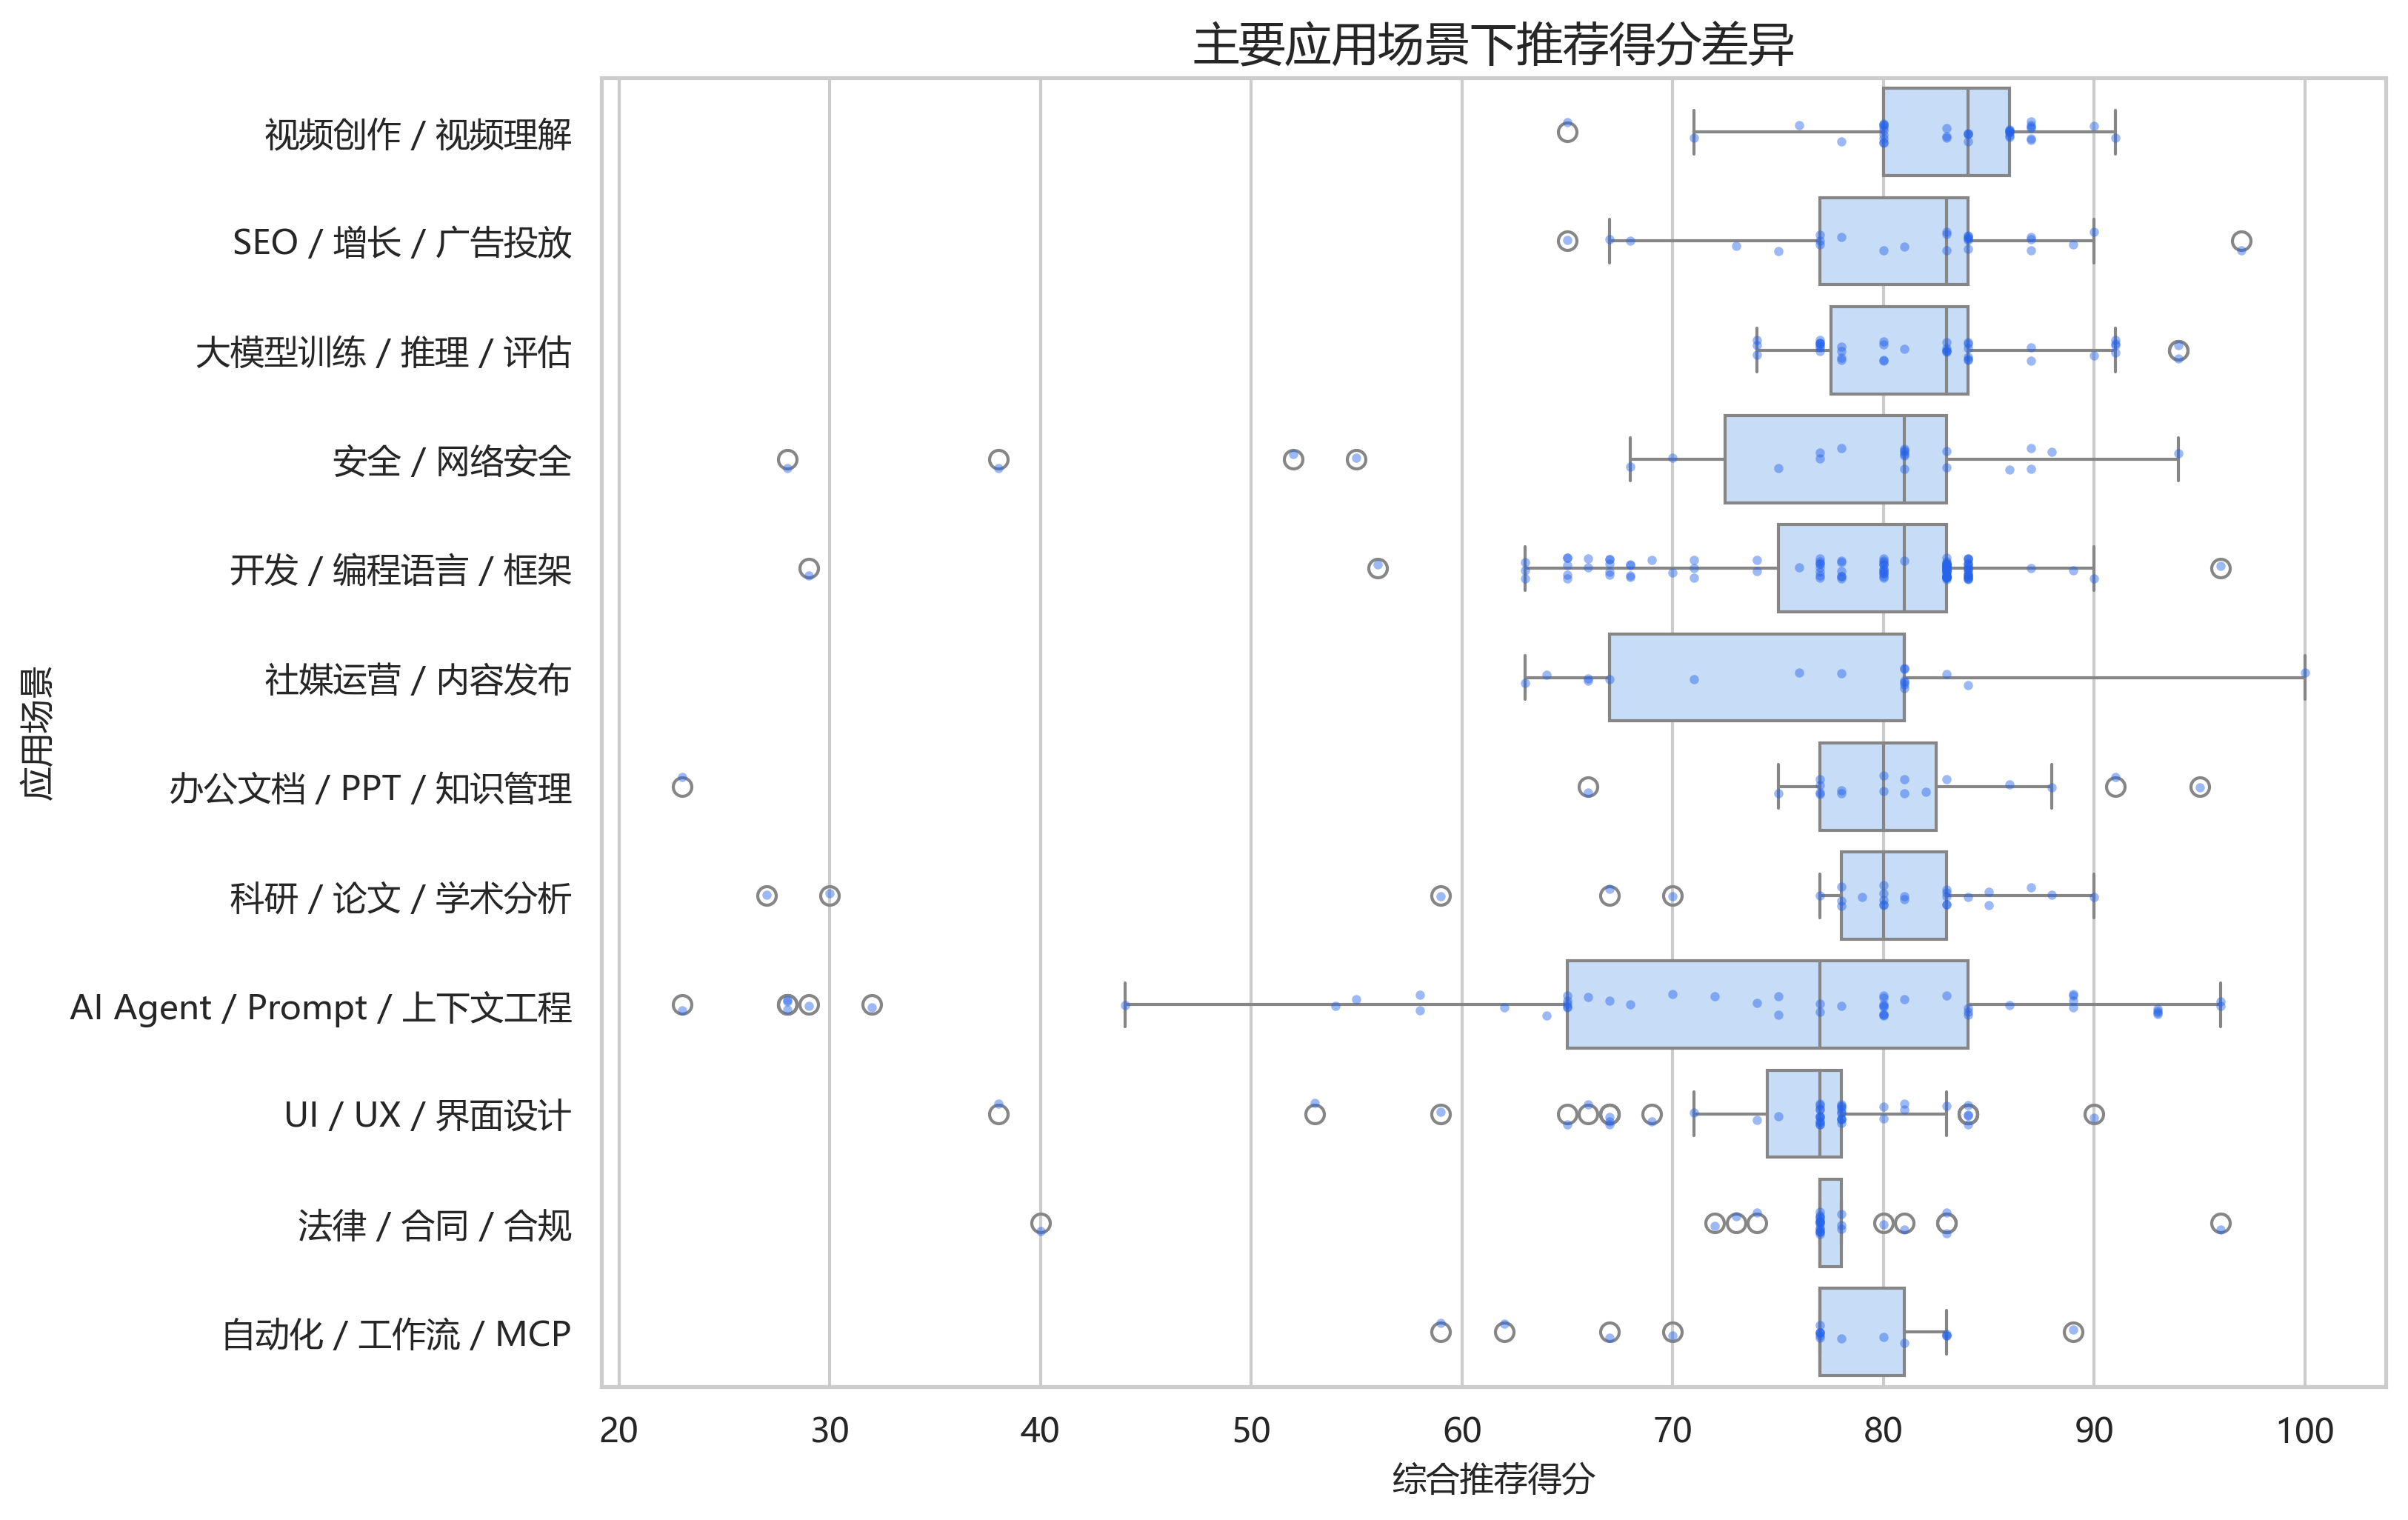

**图6 主要应用场景下推荐得分差异。** 该图用于比较不同应用场景 Skill 的推荐质量差异。

In [54]:
display(Image(filename=str(FIGURE_DIR / 'fig06_score_boxplot_by_scenario.png')))
display(Markdown('**图6 主要应用场景下推荐得分差异。** 该图用于比较不同应用场景 Skill 的推荐质量差异。'))

## 七、可视化分析结果：技术栈与项目质量指标

为了进一步解释推荐结果，本部分观察技术栈、GitHub Star、维护时间、README 文档长度等因素。这些内容不是研究目标本身，而是用于辅助说明为什么某些 Skill 更值得推荐。

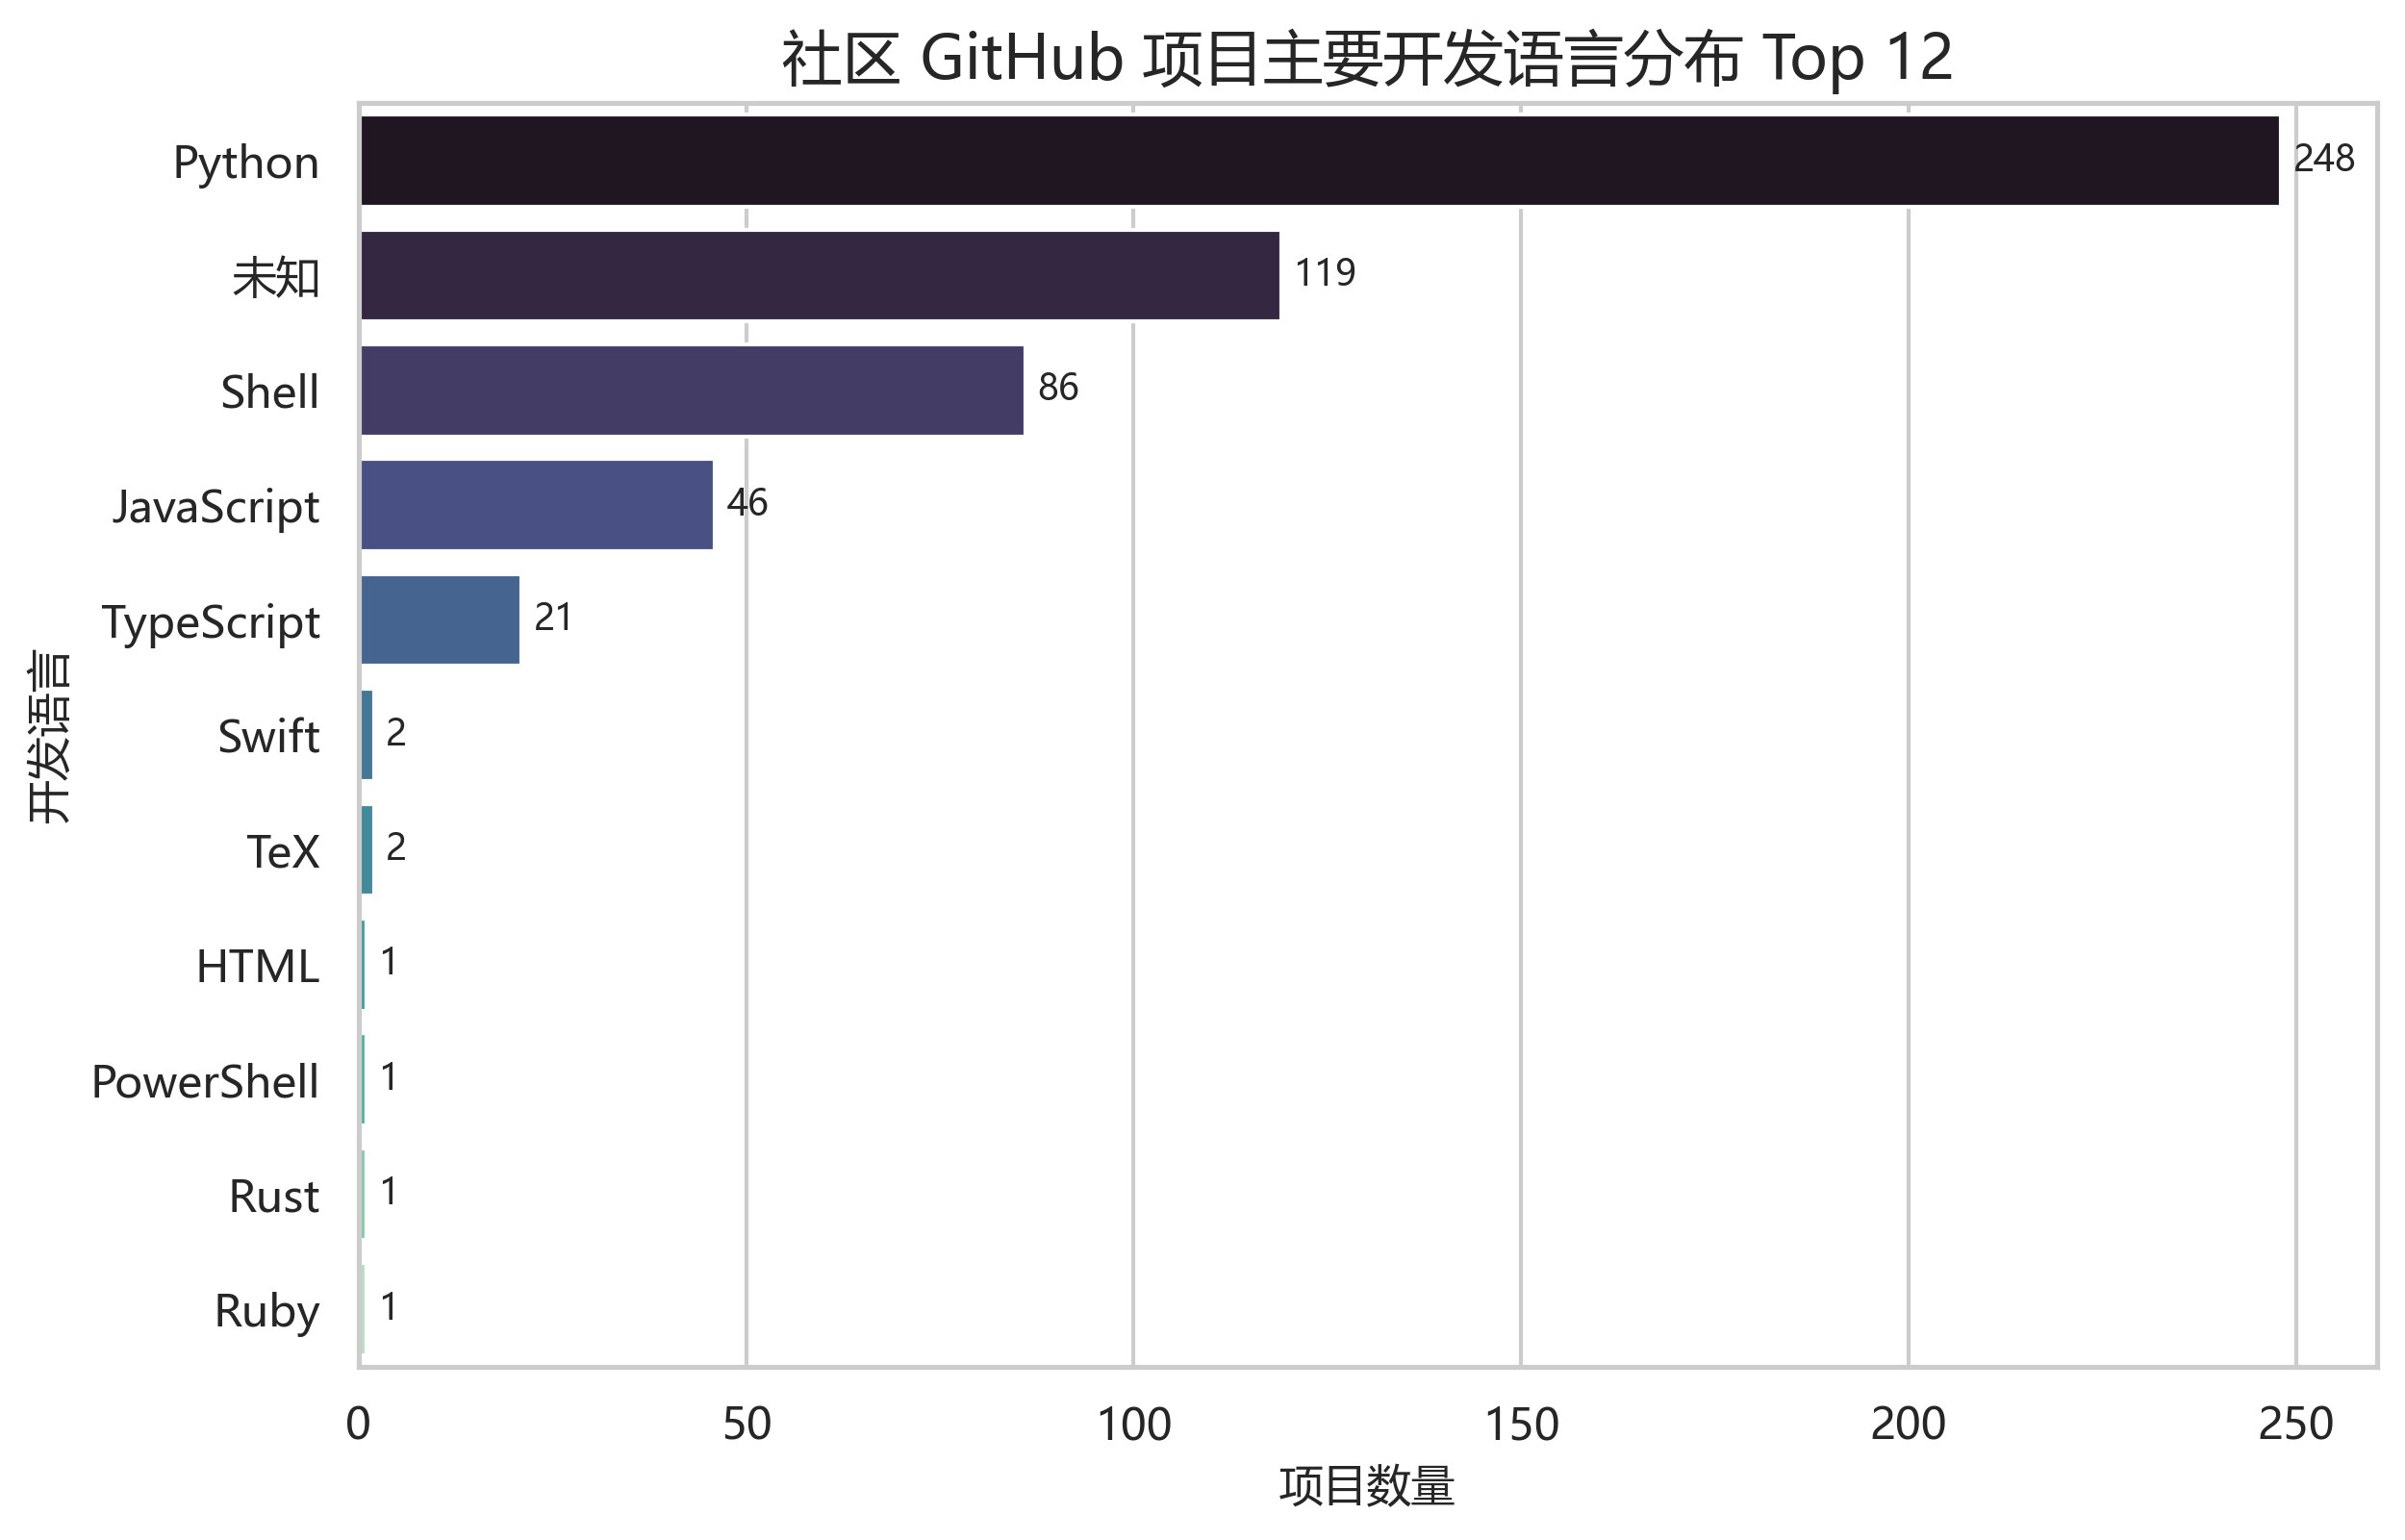

**图7 社区 GitHub 项目主要开发语言分布 Top 12。** 该图用于说明社区 Skill 的技术栈分布。

In [55]:
display(Image(filename=str(FIGURE_DIR / 'fig07_github_language_top12_bar.png')))
display(Markdown('**图7 社区 GitHub 项目主要开发语言分布 Top 12。** 该图用于说明社区 Skill 的技术栈分布。'))

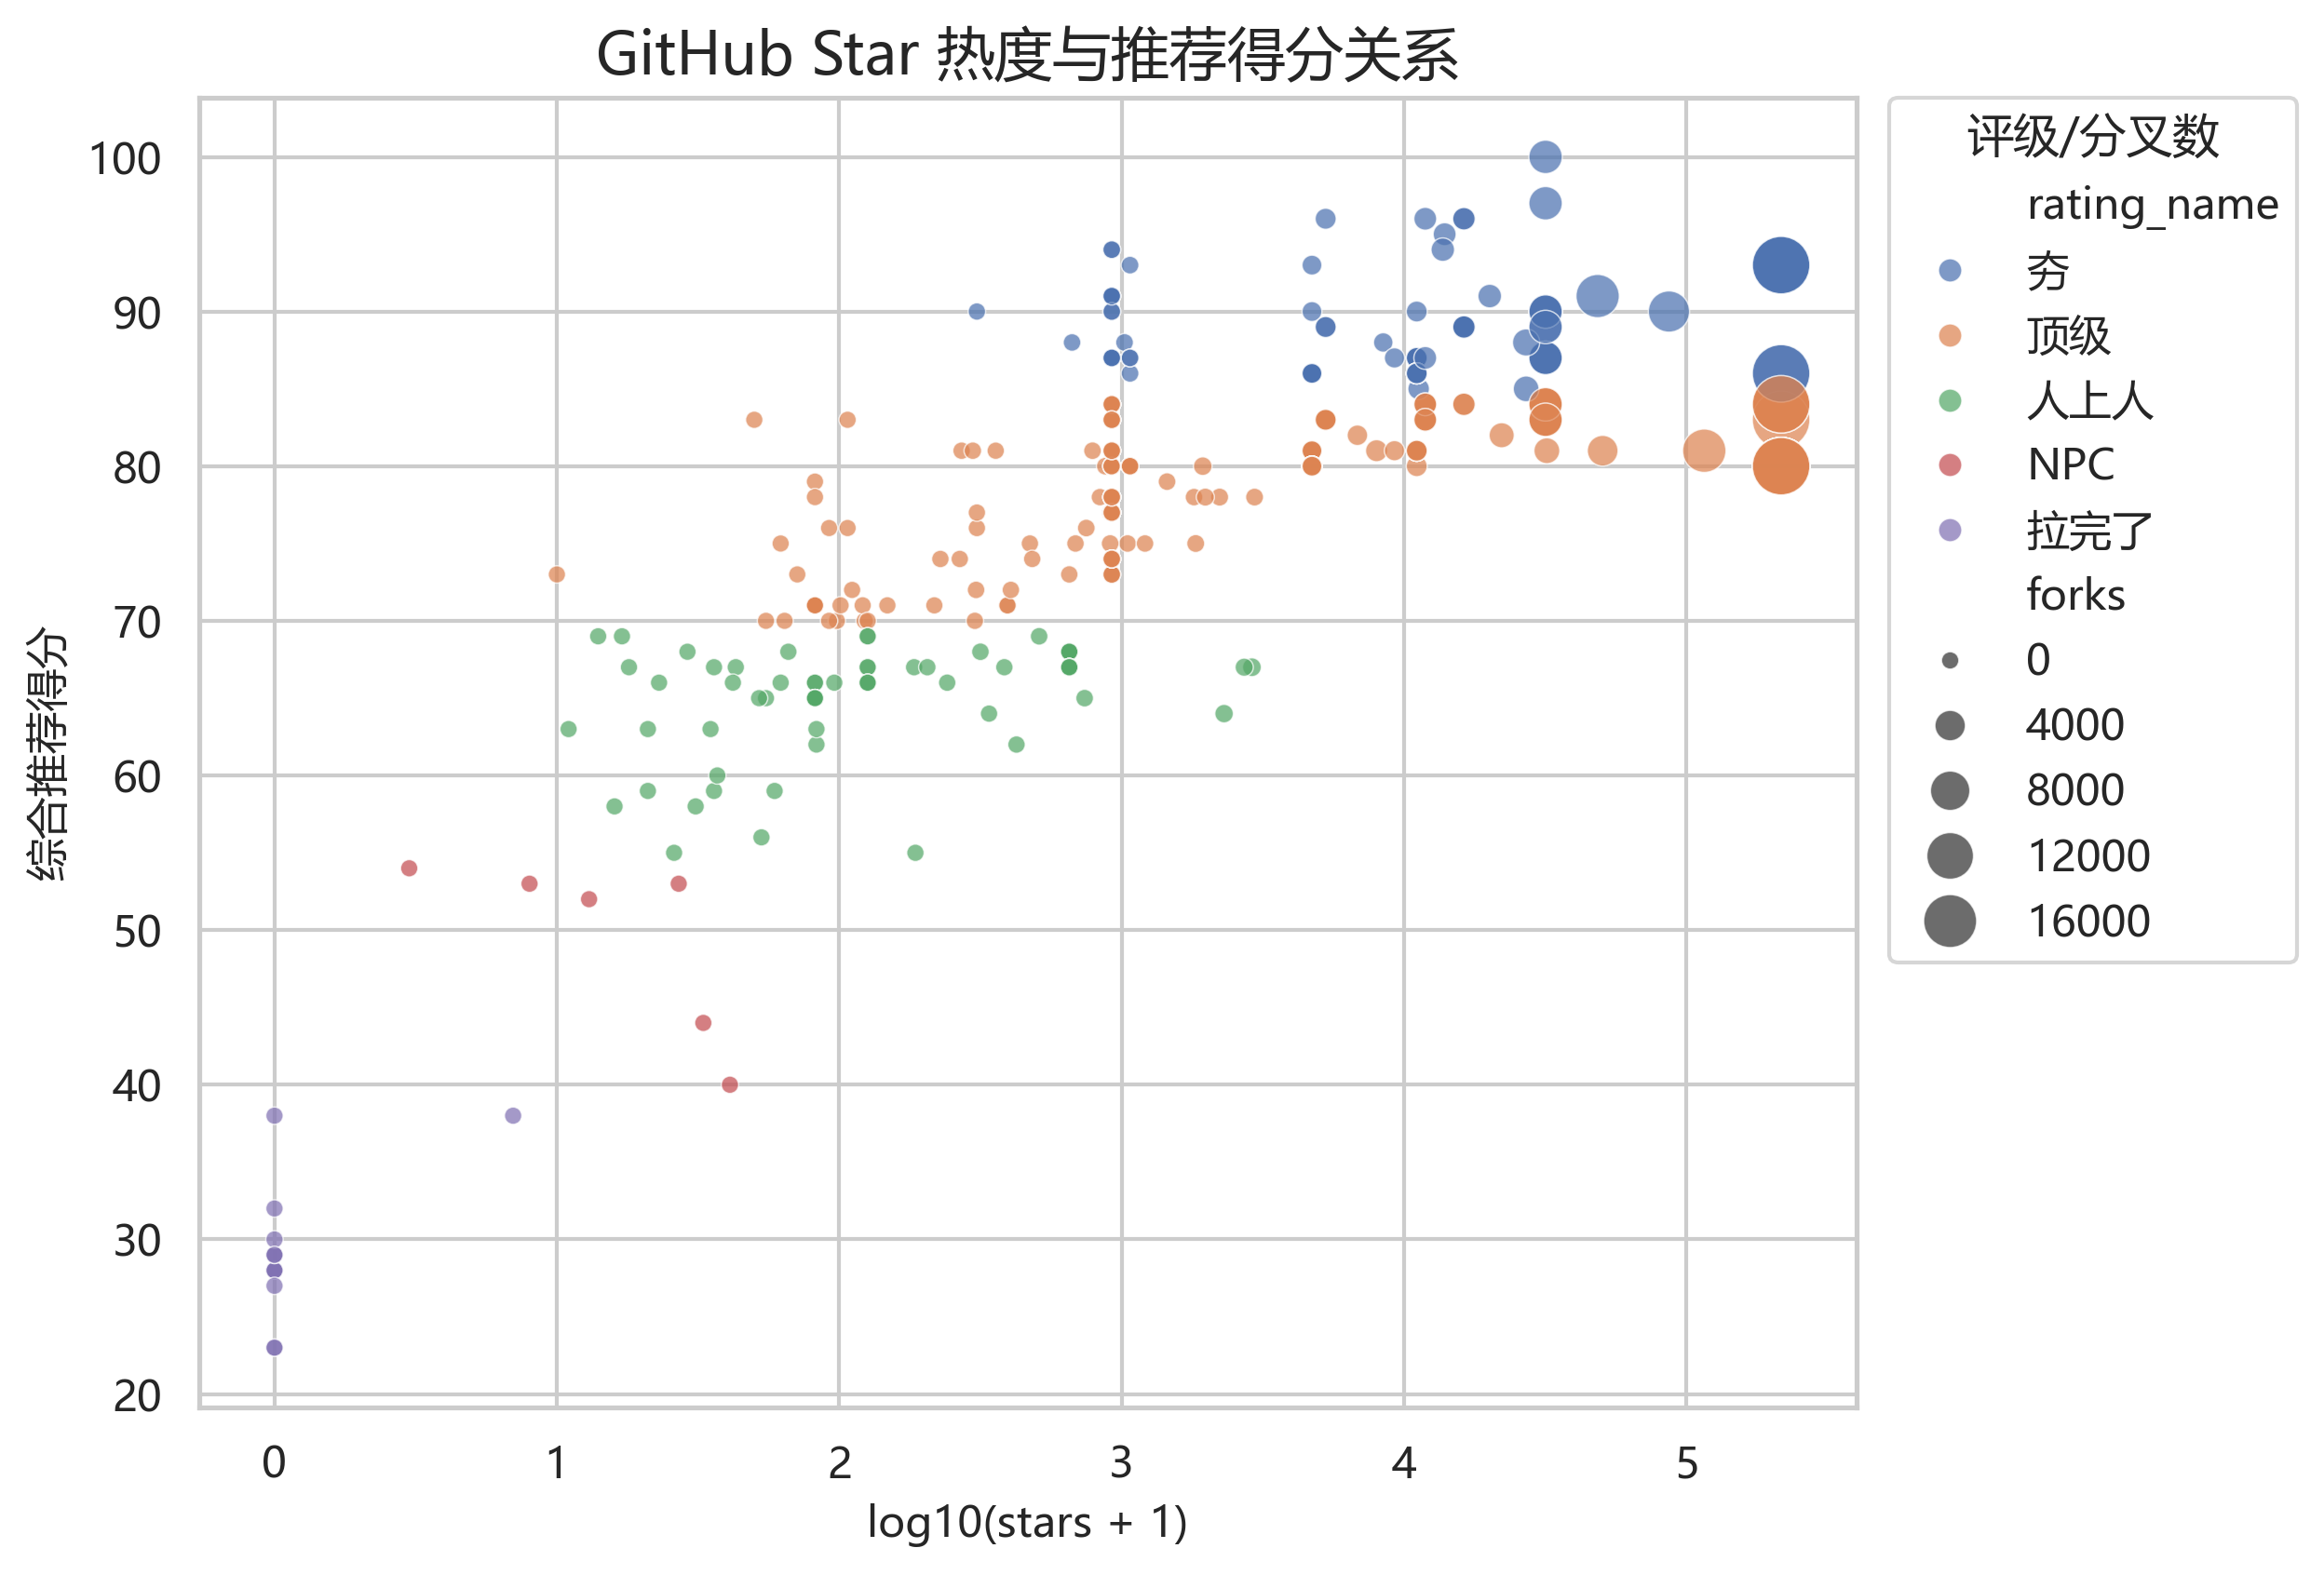

**图8 GitHub Star 热度与推荐得分关系。** 该图用于观察项目热度与推荐质量之间的关系。

In [56]:
display(Image(filename=str(FIGURE_DIR / 'fig08_stars_vs_score_scatter.png')))
display(Markdown('**图8 GitHub Star 热度与推荐得分关系。** 该图用于观察项目热度与推荐质量之间的关系。'))

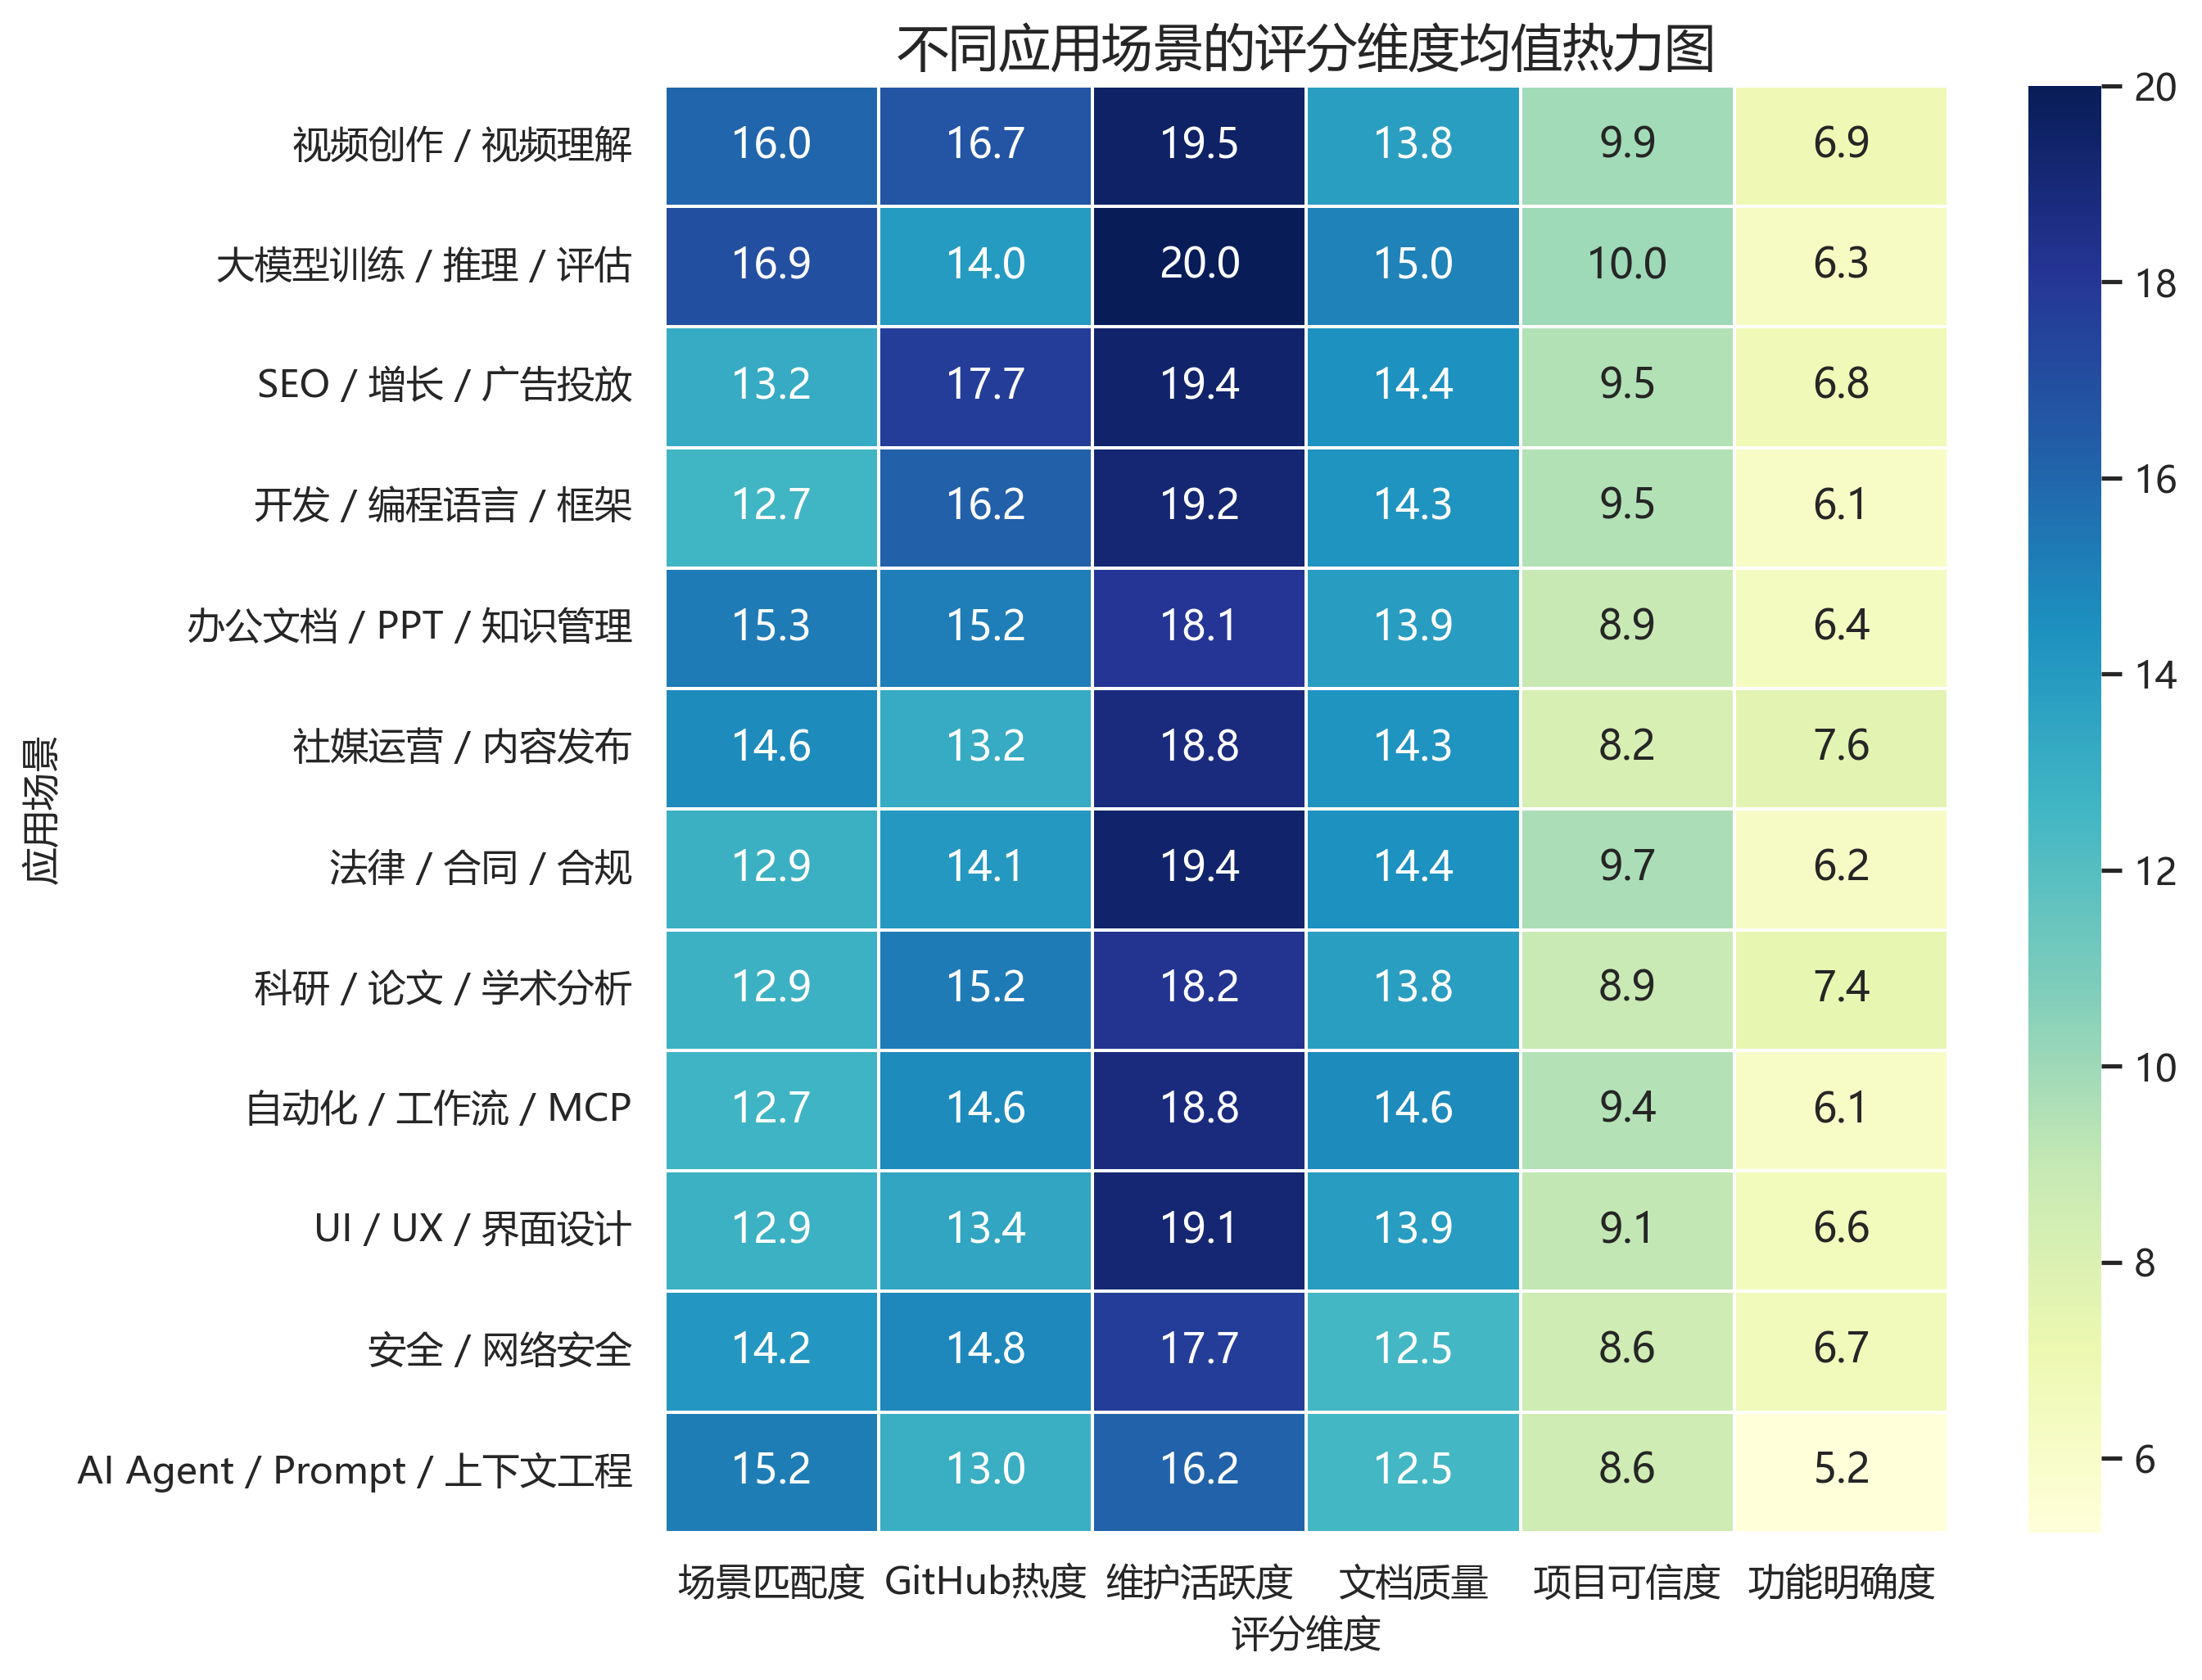

**图9 不同应用场景的评分维度均值热力图。** 该图用于解释不同场景在热度、维护、文档等维度上的差异。

In [57]:
display(Image(filename=str(FIGURE_DIR / 'fig09_score_dimension_heatmap.png')))
display(Markdown('**图9 不同应用场景的评分维度均值热力图。** 该图用于解释不同场景在热度、维护、文档等维度上的差异。'))

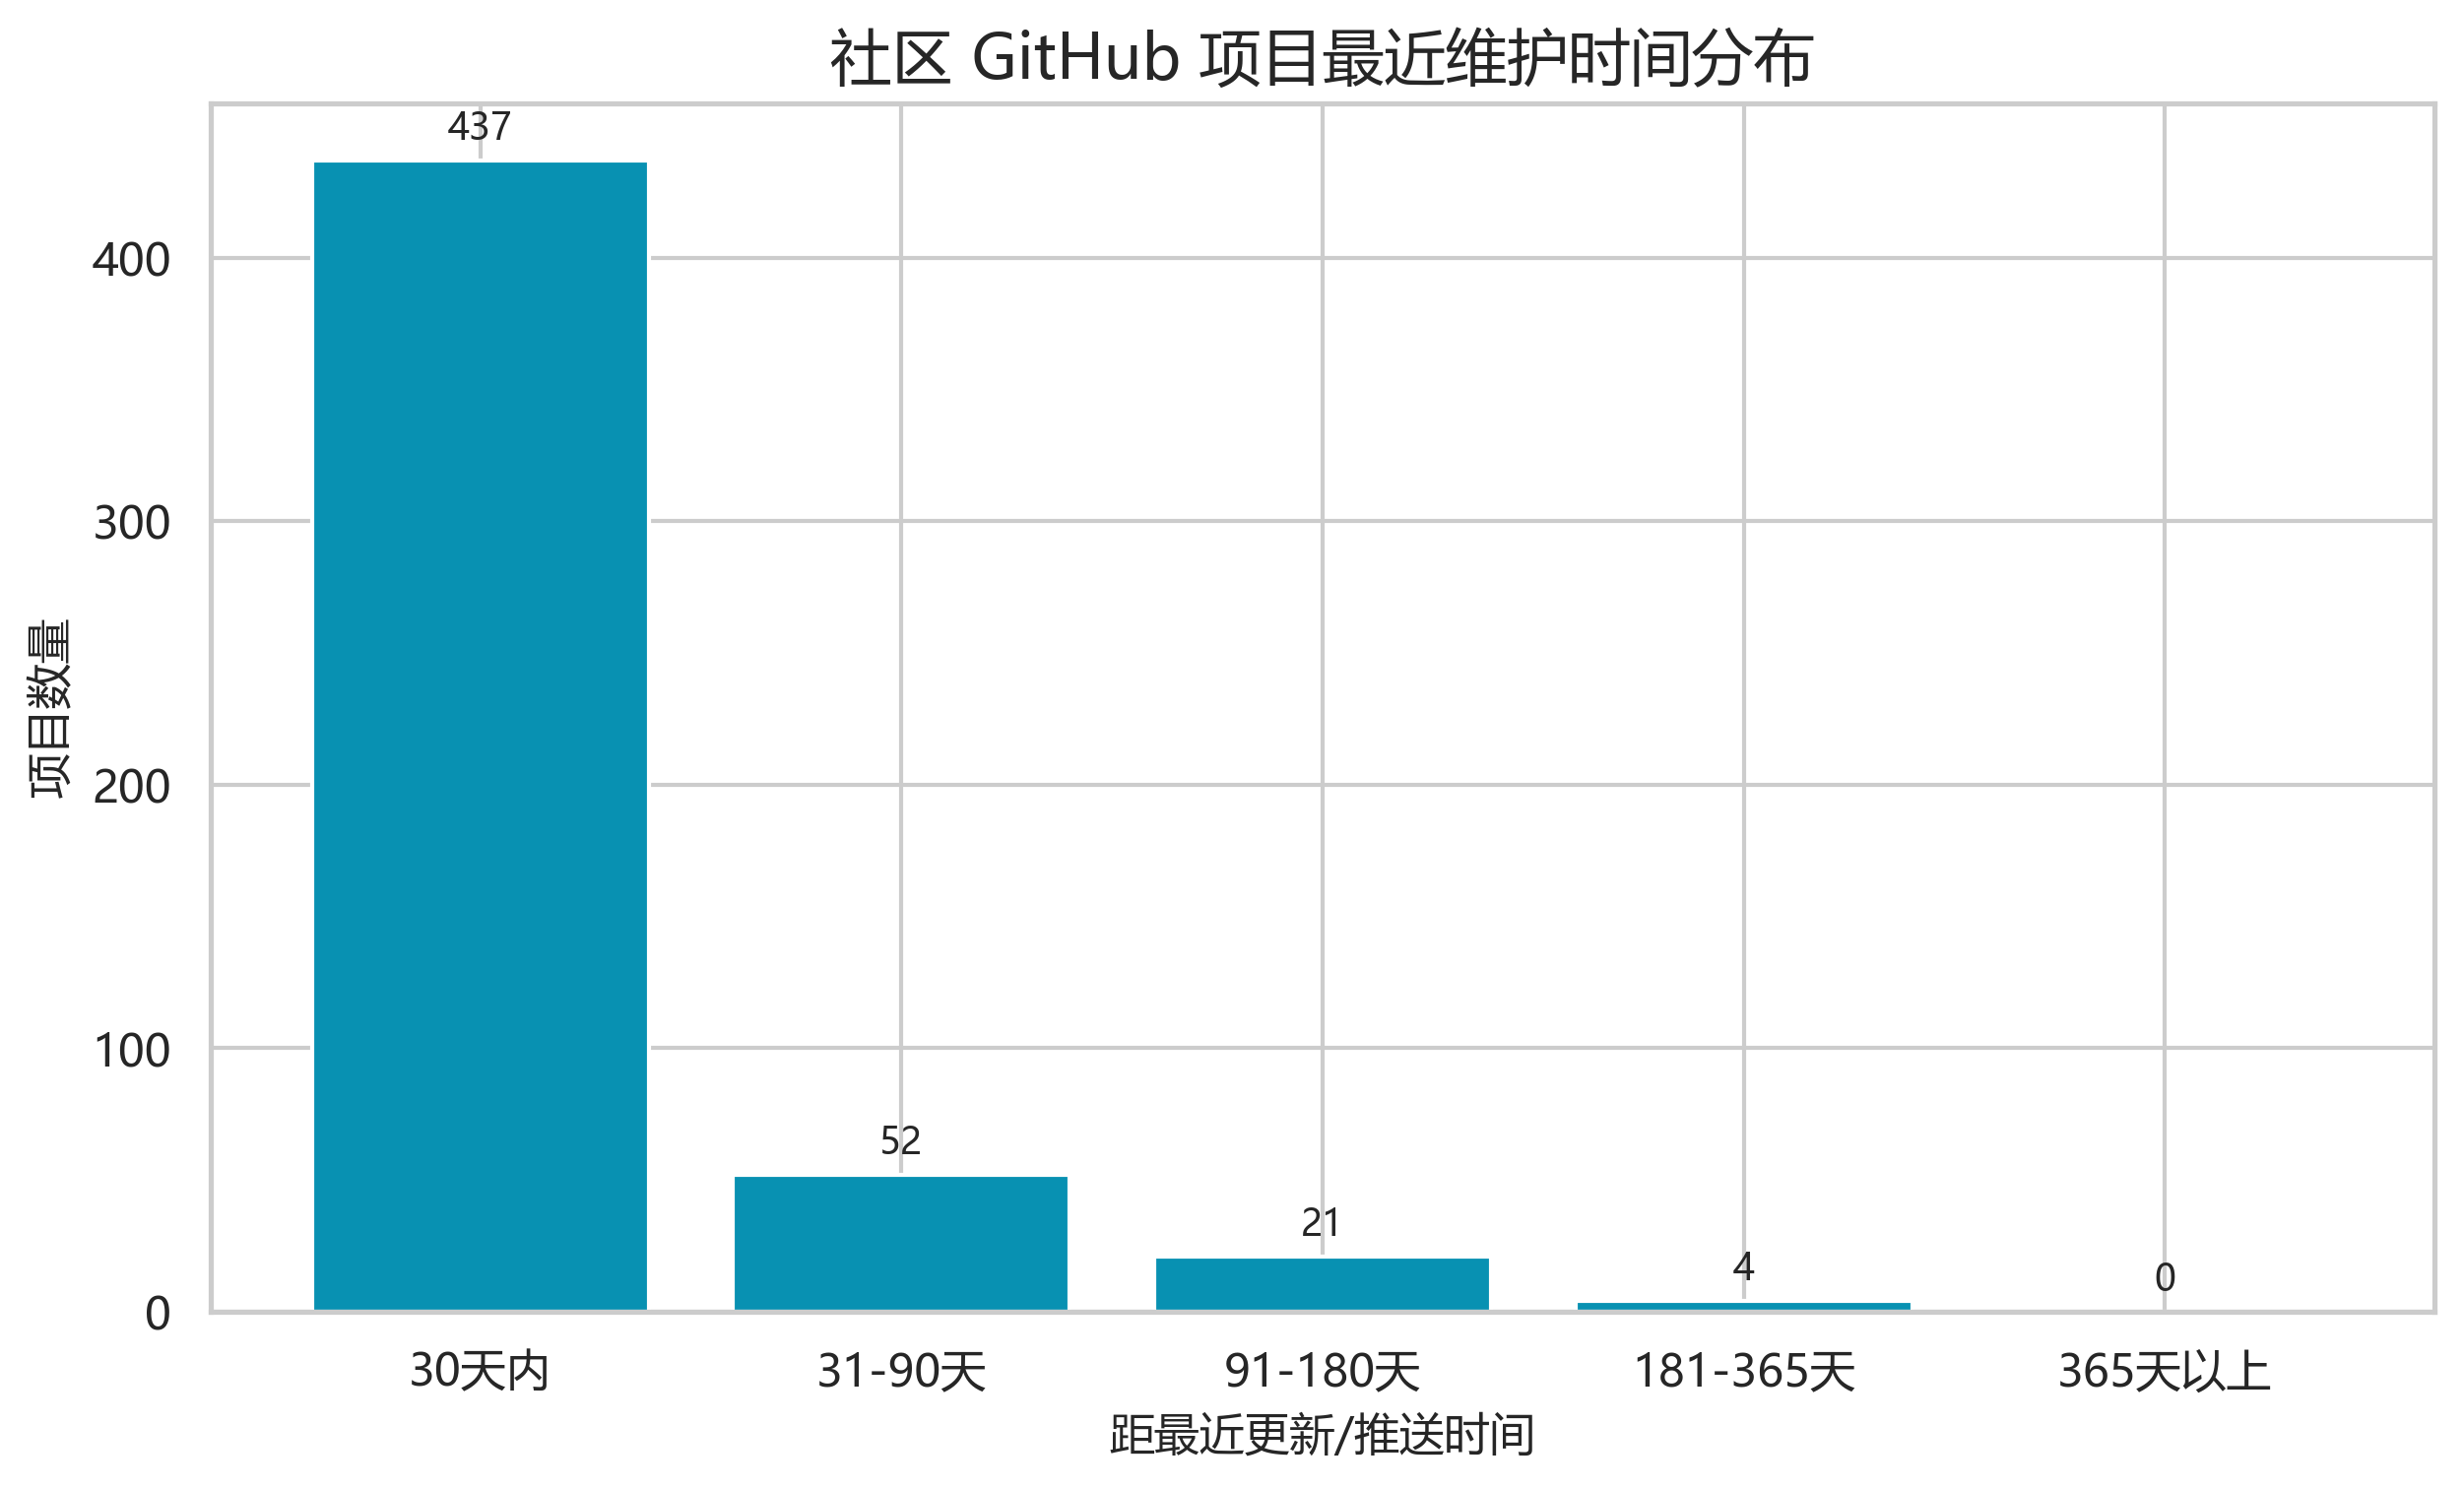

**图10 社区 GitHub 项目最近维护时间分布。** 该图用于衡量社区 Skill 项目的维护活跃程度。

In [58]:
display(Image(filename=str(FIGURE_DIR / 'fig10_maintenance_recency_bar.png')))
display(Markdown('**图10 社区 GitHub 项目最近维护时间分布。** 该图用于衡量社区 Skill 项目的维护活跃程度。'))

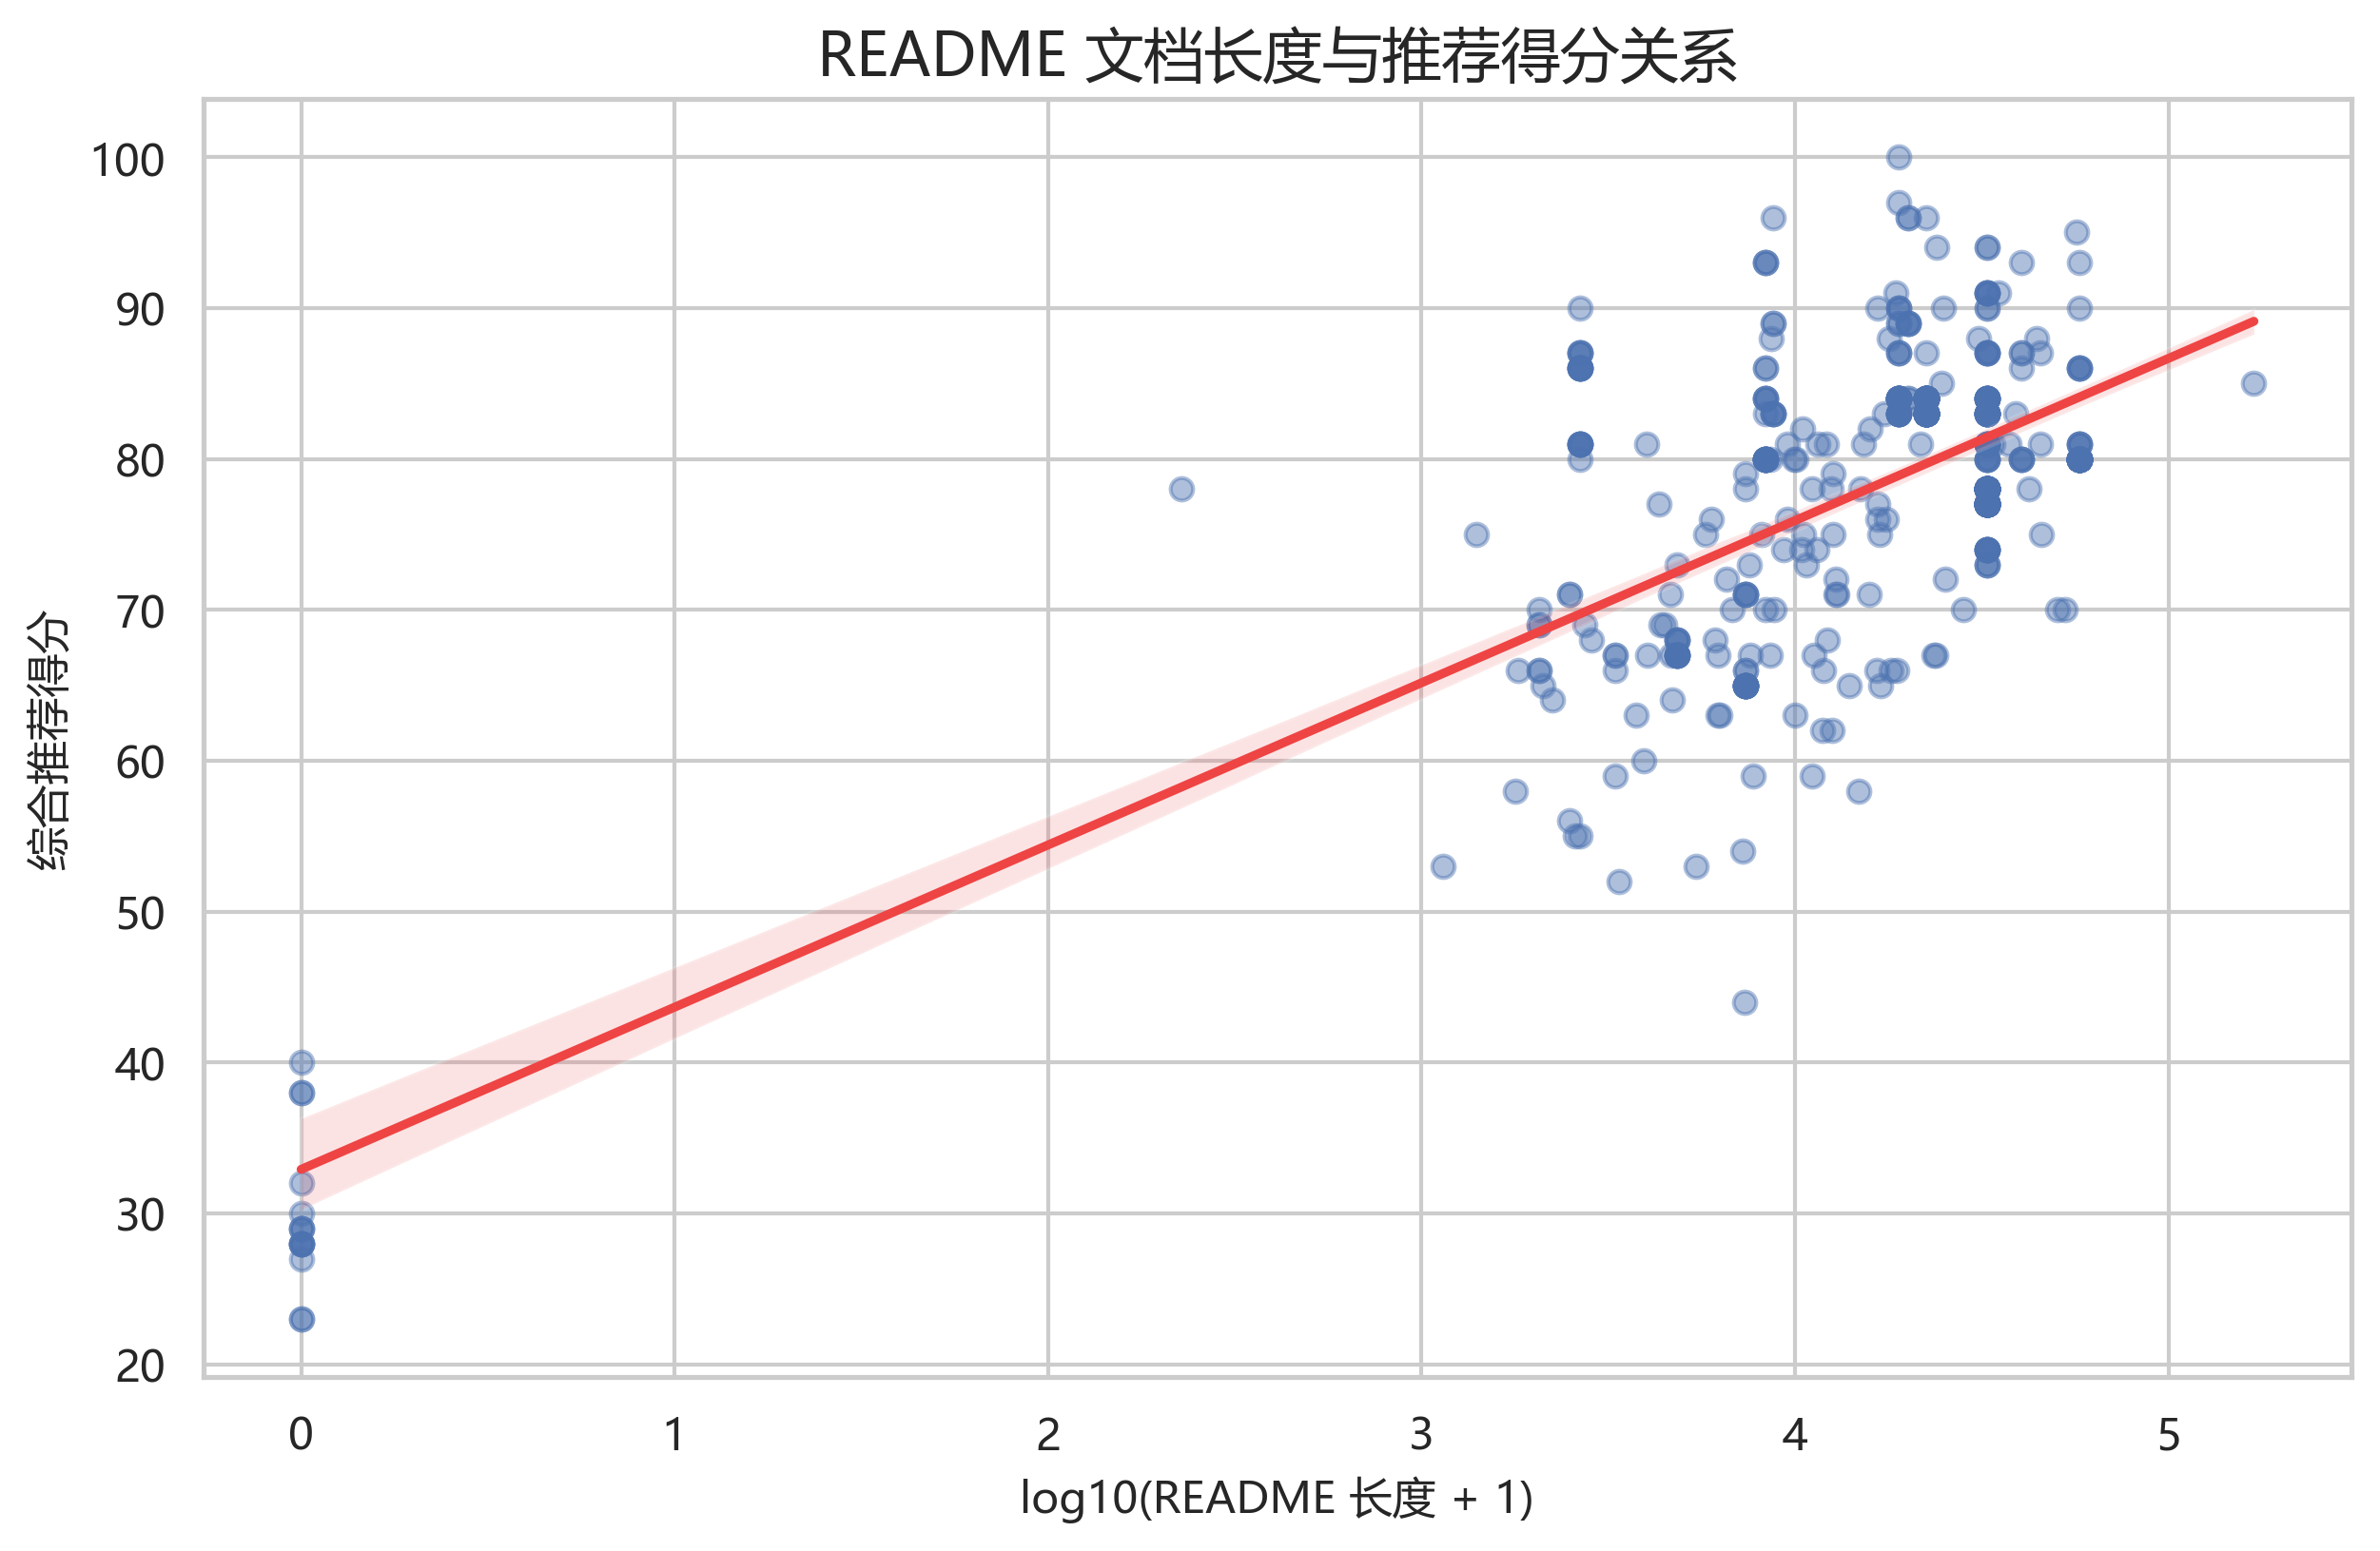

**图11 README 文档长度与推荐得分关系。** 该图用于讨论文档质量与项目推荐结果之间的关系。

In [59]:
display(Image(filename=str(FIGURE_DIR / 'fig11_readme_length_vs_score.png')))
display(Markdown('**图11 README 文档长度与推荐得分关系。** 该图用于讨论文档质量与项目推荐结果之间的关系。'))

## 八、分析小结与 Skill 选取建议

综合上述可视化分析，可以为实际选型工作归纳出以下几条具有操作性的选取原则。

**第一，先区分来源类型，再制定选取策略。** 图1 和图2 表明，官方 Skill 具有明显的机构集中特征，Microsoft、OpenAI 等头部机构提供大量标准化 Skill，适合通用任务和快速搭建原型。如果需求是文档处理（如 Anthropics 的 docx/pptx）、身份认证（如 Auth0 系列）、工作空间集成（如 Google Workspace 系列），应优先查阅官方 Skill 推荐集合；如果需求属于安全审计、SEO 分析、法律合规、电商运营等垂直领域，则应重点关注社区 Skill 分领域推荐集合。

**第二，避免单一指标偏见，尤其不能只看 Stars。** 图8 已经直观地展示了 Stars 与推荐得分之间的非线性关系——部分高 Stars 项目推荐得分并不突出，而一些中等 Stars 但维护积极、文档完整的项目反而获得了较高评分。因此，选型时应综合考虑维护活跃度（图10）、文档完整度（图11）以及项目可信度等多个维度，而非仅依据 Stars 排名。

**第三，坚持"同场景比较"原则。** 图6 揭示了不同应用场景下 Skill 得分的系统性差异：开发工具和自动化类 Skill 普遍在 GitHub 热度和维护活跃度方面占优，而部分垂直领域 Skill 虽然 Stars 较少但场景匹配度更高。这意味着不能简单跨领域对比推荐得分，应该在目标领域内部选择排名靠前的 Skill。

**第四，将维护活跃度作为硬性筛选门槛。** 图10 显示，相当一部分社区项目的最晚更新时间超过半年甚至一年以上。对于实际使用场景，建议优先选择最近一个月或三个月内有更新的项目，以降低 Skill 功能失效或依赖过时的风险。

**第五，借助多维评分模型辅助快速筛选。** 本文构建的六维推荐评分模型（场景匹配度、GitHub 热度、维护活跃度、文档质量、项目可信度、功能明确度）本质上是一套可复用的筛选框架。使用者也可以在本文基础上，根据自己的场景偏好调整各维度的权重，从而生成个性化的推荐排序。

**综上，推荐的选型流程为：** 确定应用场景 → 查看官方/社区推荐集合 → 在目标领域内按推荐得分排序 → 重点考察 Top 3~5 个 Skill 的维护状态与文档 → 结合自身技术栈和需求做出最终选择。该流程兼顾了大规模筛选的效率需求和对单个 Skill 质量的审慎判断。

## 九、分领域推荐集合结果

下表展示社区 Skill 综合推荐 Top 30，可作为推荐集合中的代表性案例。写论文时也可以结合 `outputs/tables/table02_scenario_distribution.csv` 查看每个领域的推荐 Skill。

In [60]:
top_table = pd.read_csv(TABLE_DIR / 'table03_top30_recommended_skills.csv')
display(top_table)

,Skill名称,场景类别,推荐得分,评级,具体作用,Stars,Forks,语言
0,coreyhaines31/social-content,社媒运营 / 内容发布,100,夯,社交平台内容发布与运营,31677,5223,JavaScript
1,coreyhaines31/competitor-alternatives,SEO / 增长 / 广告投放,97,夯,网站搜索优化与增长分析,31677,5223,JavaScript
2,muratcankoylan/context-fundamentals,AI Agent / Prompt / 上下文工程,96,夯,智能体工作流与任务协作,16279,1318,Python
3,czlonkowski/n8n-code-python,开发 / 编程语言 / 框架,96,夯,编程开发辅助,5272,903,Shell
4,phuryn/privacy-policy,法律 / 合同 / 合规,96,夯,法律合规与政策文档处理,11878,1401,未知
5,muratcankoylan/multi-agent-patterns,AI Agent / Prompt / 上下文工程,96,夯,智能体工作流与任务协作,16279,1318,Python
6,Skill_Seekers,办公文档 / PPT / 知识管理,95,夯,PDF 文档处理与转换,13911,1439,Python
7,NVIDIA/NeMo-Evaluator-Launcher/launching-evals,大模型训练 / 推理 / 评估,94,夯,大语言模型训练、推理或评估,921,109,Python
8,NVIDIA/Model-Optimizer/launching-evals,大模型训练 / 推理 / 评估,94,夯,大语言模型训练、推理或评估,921,109,Python
9,mukul975/Anthropic-Cybersecurity-Skills,安全 / 网络安全,94,夯,安全审计与漏洞防护,13704,1603,Python


## 九、总推荐集合表

本部分给出论文最核心的总推荐集合，包括官方 Skill 集合和社区分领域 Skill 推荐集合。官方表按公司/机构汇总，社区表按场景类别列出每类 1 到 8 个推荐 Skill。

### 9.1 官方 Skill 推荐集合

官方 Skill 推荐集合按公司/机构统计 Skill 数量，并为每个公司/机构列出 3 个代表 Skill。官方 Skill 不使用 Stars、Forks、语言等社区 GitHub 指标。

In [61]:
official_collection = pd.read_csv(TABLE_DIR / 'table05_official_skill_recommendation_collection.csv')
display(official_collection)

,公司/机构,Skill数量,代表Skill1,代表Skill2,代表Skill3
0,microsoft,133,microsoft/cloud-solution-architect - 综合型人工智能技能应用,microsoft/continual-learning - 综合型人工智能技能应用,microsoft/copilot-sdk - 综合型人工智能技能应用
1,openai,42,openai/cloudflare-deploy - 综合型人工智能技能应用,openai/develop-web-game - 综合型人工智能技能应用,openai/doc - 文档处理与知识整理
2,getsentry,28,getsentry/sentry-sdk-setup - 综合型人工智能技能应用,getsentry/sentry-workflow - 自动化工作流搭建,getsentry/sentry-fix-issues - 工具协议集成与自动化
3,garrytan,27,garrytan/office-hours - 综合型人工智能技能应用,garrytan/plan-ceo-review - 综合型人工智能技能应用,garrytan/plan-eng-review - 综合型人工智能技能应用
4,flutter,22,flutter/flutter-adding-home-screen-widgets - 综...,flutter/flutter-animating-apps - 综合型人工智能技能应用,flutter/flutter-architecting-apps - 综合型人工智能技能应用
5,trailofbits,21,trailofbits/ask-questions-if-underspecified - ...,trailofbits/audit-context-building - 综合型人工智能技能应用,trailofbits/building-secure-contracts - 安全审计与漏洞防护
6,anthropics,17,anthropics/docx - 文档处理与知识整理,anthropics/doc-coauthoring - 文档处理与知识整理,anthropics/pptx - PPT 生成与演示文稿处理
7,googleworkspace,17,googleworkspace/gws-shared - 综合型人工智能技能应用,googleworkspace/gws-drive - 综合型人工智能技能应用,googleworkspace/gws-sheets - 综合型人工智能技能应用
8,fal-ai-community,15,fal-ai-community/fal-3d - 图片生成与编辑,fal-ai-community/fal-audio - 音频生成、转录或处理,fal-ai-community/fal-generate - 视频生成、理解或处理
9,auth0,14,auth0/auth0-android - 综合型人工智能技能应用,auth0/auth0-angular - 前端应用开发,auth0/auth0-aspnetcore-api - 综合型人工智能技能应用


### 9.2 社区 Skill 分领域推荐集合

社区 Skill 推荐集合按场景类别组织，每个类别最多保留 5 个 Skill；正式推荐要求推荐得分不低于 70 分。如果某一类别没有 70 分以上 Skill，则只保留该类别最高分 1 个作为候选推荐。下面先展示分领域推荐摘要表，再展示按类别组织的完整明细表。

In [62]:
community_summary = pd.read_csv(TABLE_DIR / 'table07_community_recommendation_summary.csv')
display(community_summary)

community_collection = pd.read_csv(TABLE_DIR / 'table06_community_skill_recommendation_collection.csv')
display(community_collection)

,Skill名称,场景类别,推荐得分,评级,具体作用,Stars,Forks,语言
0,mukul975/Anthropic-Cybersecurity-Skills,安全 / 网络安全,94,⭐⭐⭐⭐⭐ 夯,安全审计与漏洞防护,13704,1603,Python
1,prompt-security/clawsec,安全 / 网络安全,88,⭐⭐⭐⭐⭐ 夯,安全审计与漏洞防护,1022,105,JavaScript
2,google/cloud/google-cloud-waf-security,安全 / 网络安全,87,⭐⭐⭐⭐⭐ 夯,安全审计与漏洞防护,11081,885,Python
3,NeoLabHQ/code-review,安全 / 网络安全,87,⭐⭐⭐⭐⭐ 夯,安全审计与漏洞防护,1069,98,TypeScript
4,obra/defense-in-depth,安全 / 网络安全,86,⭐⭐⭐⭐⭐ 夯,安全审计与漏洞防护,216177,19252,Shell
...,...,...,...,...,...,...,...,...
106,NVIDIA/Model-Optimizer/monitor,大模型训练 / 推理 / 评估,87,⭐⭐⭐⭐⭐ 夯,大模型训练、推理与评估,921,109,Python
107,NVIDIA/rag/rag-blueprint,数据 / 向量 / RAG / 搜索,78,⭐⭐⭐⭐ 顶级,检索增强生成与知识问答,921,109,Python
108,NVIDIA/TileGym/improve-cutile-kernel-perf,其他 / 暂未明确,74,⭐⭐⭐⭐ 顶级,综合型人工智能技能应用,921,109,Python
109,NVIDIA/cuopt/cuopt-server-common,其他 / 暂未明确,73,⭐⭐⭐⭐ 顶级,综合型人工智能技能应用,921,109,Python


## 十、结论与论文写作建议

围绕“构建各领域 Skill 推荐集合”这一目标，可以形成以下结论：

1. 本项目将分散的 AI Agent Skills 数据整理为可分析、可推荐的结构化数据。
2. 通过领域划分，可以把社区 Skill 组织成安全、科研、开发、自动化、RAG、内容创作、营销增长等多个推荐集合。
3. 通过综合评分，可以在每个领域中筛选出更值得优先关注的 Skill，避免只依赖人工主观判断。
4. 可视化图表用于解释推荐集合的构成，包括领域分布、推荐评级、评分差异和 GitHub 指标特征。
5. 后续可以继续优化推荐模型，例如增加 Issue 活跃度、贡献者数量、下载量、README 语义质量等指标。

论文写作时建议按照“项目背景—推荐集合构建目标—数据来源—领域划分方法—评分模型—各领域推荐结果—可视化分析—结论”的顺序组织。